# Master PCA Runner (All Events + Dynamic Plot Families)

Keeps the same all-events loading/alignment workflow and adds dynamic legacy PCA plot types from the all-in-one notebook.


## Imports
Loads prep/plot modules plus basic libraries used for config and quick checks.


In [1]:
from pathlib import Path
import importlib
import numpy as np
import pandas as pd

import pca_data_prep as prep
import pca_plotting as plots
import verify_data as verify

# Always reload local modules so notebook uses latest patched code.
prep = importlib.reload(prep)
plots = importlib.reload(plots)

print('pca_data_prep path:', Path(prep.__file__).resolve())
if not hasattr(prep, 'extract_probe_letters'):
    raise AttributeError(
        'Loaded pca_data_prep does not expose extract_probe_letters. '
        'Restart kernel and re-run this cell, then confirm it points to master/pca_data_prep.py.'
    )


pca_data_prep path: C:\Users\user\Documents\github\PCA_on_neural_data\master_02\pca_data_prep.py


#### ======================================================================================================================================================================================================================================
## Manually set all 6 paths
#### ======================================================================================================================================================================================================================================


In [2]:
# SET #1: Path to the NWB file for this session (on the neural data computer)
NWB_PATH = Path(r"G:\Grant\neuropixels\nwb\Reach15")

# SET #2: Path to the bombcell root folder for this session (on the neural data computer)
BOMBCELL_ROOT_FOR_AUTO_BUILD = Path(r"H:\Grant\Neuropixels\Kilosort_Recordings\Reach15_20260201_session007_NP_Recording_Number02_2026-02-01_18-25-00\bombcell\bombcell_batch_20260222_1618")

# SET #3: Session name (for labeling plots)
SESSION_NAME = Path(r'Reach15_20260201_session007_NP_Recording_Number02_2026-02-01_18-25-00')

# SET #4: Paths to trial index files (these are from the behavior video acquisition computer, not the neural data computer)
baseline_trials_index_path = r"G:\Grant\behavior_data\DLC_net\grant_reach15_swingDoor-christie\videos\20260201\christielab\session007\20260201_christielab_session007_baseline_trial_numbers_tone2_aligned.npy"
washout_trials_index_path = r"G:\Grant\behavior_data\DLC_net\grant_reach15_swingDoor-christie\videos\20260201\christielab\session007\20260201_christielab_session007_washout_trial_numbers_tone2_aligned.npy"
optoicalStim_trials_index_path = r"G:\Grant\behavior_data\DLC_net\grant_reach15_swingDoor-christie\videos\20260201\christielab\session007\20260201_christielab_session007_stim_allowed_trial_numbers_tone2_aligned.npy"


#### Veirfy all 6 Manually set paths exist in their correct FULL form before attempting to load them in

In [3]:
# SET #1: Validate NWB file path  
if not NWB_PATH.exists():
    raise FileNotFoundError(f"NWB file not found at {NWB_PATH}. Please check the path and try again.")

# SET #2: Validate bombcell root path and expected folder structure
FULL_BOMBCELL_PATH = BOMBCELL_ROOT_FOR_AUTO_BUILD / "kilosort4_A" / "bombcell"
if not FULL_BOMBCELL_PATH.exists():
    raise FileNotFoundError(
        f"Expected to find bombcell data at {FULL_BOMBCELL_PATH}, but it does not exist. "
        "Please check that BOMBCELL_ROOT_FOR_AUTO_BUILD is set correctly and that the folder structure matches the expected format."
    )


# SET #3: Validate the NP session name and construct paths to data, with error handling
FULL_SESSION_PATH = r'H:\Grant\Neuropixels\Kilosort_Recordings' / SESSION_NAME
if not FULL_SESSION_PATH.exists():
    raise FileNotFoundError(
        f"Expected to find session data at {FULL_SESSION_PATH}, but it does not exist. "
        "Please check that SESSION_NAME is set correctly and that the folder structure matches the expected format."
    )


# SET #4: Validate trial index file paths
if not Path(baseline_trials_index_path).exists():
    raise FileNotFoundError(f"Baseline trials index file not found at {baseline_trials_index_path}. Please check the path and try again.")
if not Path(washout_trials_index_path).exists():
    raise FileNotFoundError(f"Washout trials index file not found at {washout_trials_index_path}. Please check the path and try again.")
if not Path(optoicalStim_trials_index_path).exists():
    raise FileNotFoundError(f"Optical stim trials index file not found at {optoicalStim_trials_index_path}. Please check the path and try again.")


#### =======================================================================================================================================================================================================================================
## Begin loading and processing data
#### =======================================================================================================================================================================================================================================


### SETS #1 & #2: Load (NWB + Bombcell) & Load or Auto-Build Processed Bundle
Loads `merged_dic`, `stim_df`, and `pca_event_meta` from `processed_data/bundle_latest`.
If the bundle is missing, this cell can auto-build it from an NWB file for the current recording.

In [4]:
bundle, merged_dic, stim_df, df_stim, pca_event_meta, extras, meta, PROCESSED_BUNDLE_DIR = prep.load_or_build_processed_bundle(
    nwb_path_for_auto_build=NWB_PATH,
    bombcell_root_for_auto_build="",
    use_bombcell_if_available=True,
    auto_build_bundle_if_missing=True,
    auto_rebuild_if_bombcell_missing=True,
    required_filenames=("merged_dic.pkl", "stim_df.pkl", "pca_event_meta.pkl"),
    verbose=True,
)

print('\n\n NOTE: pca_event_meta key will be WRONG at this point. it gets properly built during the prep.build_pca_event_meta_and_event_times(...) call in a later cell')

Bombcell root not set. Set bombcell_root_for_auto_build to merge in_brainRegion/brain_region/bc_label.
Loaded bundle: processed_data\bundle_latest
Meta: {'created_at': '2026-02-27T17:36:14.067584', 'files': ['merged_dic.pkl', 'stim_df.pkl', 'pca_event_meta.pkl', 'extras.pkl'], 'n_probes': 6, 'n_events_stim_df': 1352824, 'n_events_pca_meta': 1352824}
pca_event_meta rows: 1352824


 NOTE: pca_event_meta key will be WRONG at this point. it gets properly built during the prep.build_pca_event_meta_and_event_times(...) call in a later cell


### SET #3: Load Neuropixel Session Root & Create Save Dir for Plots

In [5]:
FULL_SESSION_PATH = r'H:\Grant\Neuropixels\Kilosort_Recordings' / SESSION_NAME
PLOTS_SAVE_ROOT = FULL_SESSION_PATH / "analysis" / "PCA"

if PLOTS_SAVE_ROOT.exists():
    print(f"Save directory exists: {PLOTS_SAVE_ROOT}")
else:
    print(f"Save directory did not exist, creating: {PLOTS_SAVE_ROOT}")
    PLOTS_SAVE_ROOT.mkdir(parents=True, exist_ok=True)


Save directory exists: H:\Grant\Neuropixels\Kilosort_Recordings\Reach15_20260201_session007_NP_Recording_Number02_2026-02-01_18-25-00\analysis\PCA


### SET #4: Loads the trial index files 

In [6]:
baseline_trials_idx = np.load(baseline_trials_index_path, allow_pickle=True)
washout_trials_idx = np.load(washout_trials_index_path, allow_pickle=True)
optoicalStim_trials_idx = np.load(optoicalStim_trials_index_path, allow_pickle=True)


### Fix the pca_events_meta dataframe and load in all stimulus start_times as arrays

In [7]:
pca_event_meta, tone1_start_times, tone2_start_times, stimROI_start_times, optical_start_times, all_stimROI_triggers_start_times = prep.build_pca_event_meta_and_event_times(
    stim_df=stim_df,
    baseline_trials_idx=baseline_trials_idx,
    optoicalStim_trials_idx=optoicalStim_trials_idx,
    washout_trials_idx=washout_trials_idx
)

#### =======================================================================================================================================================================================================================================
## Verify Loaded Data
#### =======================================================================================================================================================================================================================================


#### CHECK #1 - that the trial numbers and structure for baseline, stimulation, and washout trials are correct
- if the structure of any epoch is WRONG will fix the structure if its incorrect

Total Baseline Trials:  20
Total Washout epochs:  5
Total Optical Stim epochs:  5

baseline_trials_idx [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20]
optoicalStim_trials_idx [list([21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40])
 list([61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80])
 list([101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120])
 list([141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160])
 list([181, 182, 183, 184, 185, 186, 187, 188, 189, 190, 191, 192, 193, 194, 195, 196, 197, 198, 199, 200, 221, 222, 223, 224, 225, 226, 227, 228, 229, 230, 231, 232, 233, 234, 235, 236, 237, 238, 239, 240, 261, 262, 263, 264, 265, 266, 267, 268, 269, 270])]
washout_trials_idx [list([41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60])
 list([81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92

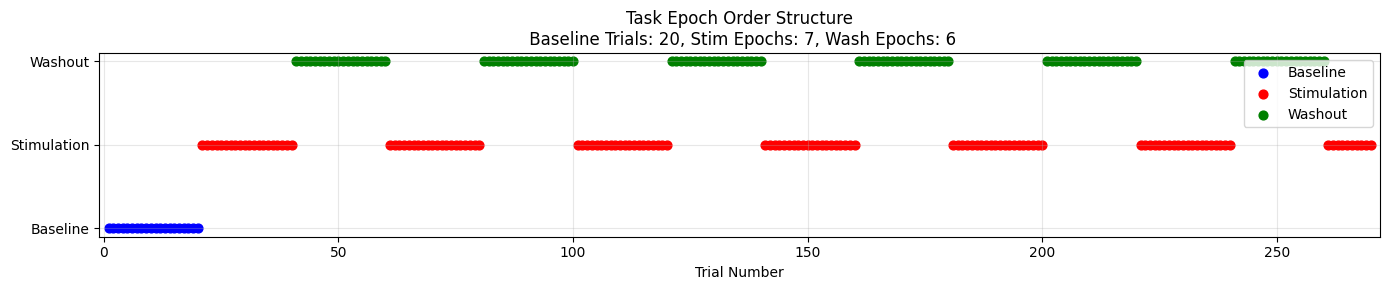

Epoch summaries (trial indices as used for verification):
  Baseline: 1..20 (n=20)
  Stim 1:  21..40 (n=20)
  Stim 2:  61..80 (n=20)
  Stim 3:  101..120 (n=20)
  Stim 4:  141..160 (n=20)
  Stim 5:  181..200 (n=20)
  Stim 6:  221..240 (n=20)
  Stim 7:  261..270 (n=10)
  Wash 1:  41..60 (n=20)
  Wash 2:  81..100 (n=20)
  Wash 3:  121..140 (n=20)
  Wash 4:  161..180 (n=20)
  Wash 5:  201..220 (n=20)
  Wash 6:  241..260 (n=20)

WARNINGS:
 - Stim epochs (7) != Wash epochs (6); checking first 6 pairs.

FAILED checks:
 - Stim epoch 7 size = 10 (expected 20).
 - Stim epochs = 7 (expected 5).
 - Wash epochs = 6 (expected 5).


In [8]:
result = verify.verify_task_epoch_structure(
    baseline_trials_idx,
    optoicalStim_trials_idx,
    washout_trials_idx,
    trials_per_epoch=20,
    expect_stim_epochs=5,
    expect_wash_epochs=5,
    auto_split_merged_epochs=True,
    split_mode="keep_incomplete",  # "raise" | "drop_incomplete" | "keep_incomplete"
    show_plot=True,
    verbose=True
)
# Overwrite with correct structure expected downstream
og_baseline_trials_idx = baseline_trials_idx
og_optoicalStim_trials_idx = optoicalStim_trials_idx
og_washout_trials_idx = washout_trials_idx

baseline_trials_idx = result["used_epochs"]["baseline"]
optoicalStim_trials_idx = result["used_epochs"]["stim"]
washout_trials_idx = result["used_epochs"]["wash"]

### Post epoch modification verification (cell above modified these indexs if needed)

In [9]:
# verify these events are correct it should go Baseline -> Optical Stim -> Washout (with 20 trials in each epoch)
print('Total Baseline Trials: ', len(baseline_trials_idx))
print('Total Washout epochs: ', len(washout_trials_idx))
print('Total Optical Stim epochs: ', len(optoicalStim_trials_idx))
print('')
print('baseline_trials_idx',baseline_trials_idx)
print('')
print('optoicalStim_trials_idx',optoicalStim_trials_idx)
print('')
print('washout_trials_idx',washout_trials_idx)

Total Baseline Trials:  1
Total Washout epochs:  6
Total Optical Stim epochs:  7

baseline_trials_idx [[1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 20]]

optoicalStim_trials_idx [list([21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40])
 list([61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80])
 list([101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120])
 list([141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160])
 list([181, 182, 183, 184, 185, 186, 187, 188, 189, 190, 191, 192, 193, 194, 195, 196, 197, 198, 199, 200])
 list([221, 222, 223, 224, 225, 226, 227, 228, 229, 230, 231, 232, 233, 234, 235, 236, 237, 238, 239, 240])
 list([261, 262, 263, 264, 265, 266, 267, 268, 269, 270])]

washout_trials_idx [[41 42 43 44 45 46 47 48 49 50 51 52 53 54 55 56 57 58 59 60]
 [81 82 83 84 85 86 87 88 89 90 91 92 93 94 95 96 97 98 99 100]
 [12

### Rebuild pca_event_meta with correct trial structure and check timing of stim events again

In [10]:
pca_event_meta, tone1_start_times, tone2_start_times, stimROI_start_times, optical_start_times, all_stimROI_triggers_start_times = prep.build_pca_event_meta_and_event_times(
    stim_df=stim_df,
    baseline_trials_idx=baseline_trials_idx,
    optoicalStim_trials_idx=optoicalStim_trials_idx,
    washout_trials_idx=washout_trials_idx
)

print('Total Rows in pca_event_meta: ', len(pca_event_meta))
print('Each rows = one trial')
print('\n Bellow should show the pca_event_meta seperated into the first 2 epochs. condition_epoch should match the above name\n')
print('baseline_epoch')
display(pca_event_meta[0:3])
print('stimulation_epoch_1')
display(pca_event_meta[20:23])
print('washout_epoch_1')
display(pca_event_meta[40:43])
print('stimulation_epoch_2')
display(pca_event_meta[60:63])
print('washout_epoch_2')
display(pca_event_meta[80:83])

Total Rows in pca_event_meta:  270
Each rows = one trial

 Bellow should show the pca_event_meta seperated into the first 2 epochs. condition_epoch should match the above name

baseline_epoch


,trial_index0,trial_number,start_time,condition,epoch_id,condition_epoch
0,0,1,10239.893300,baseline,0,baseline_epoch
1,1,2,10263.343867,baseline,0,baseline_epoch
2,2,3,10285.494367,baseline,0,baseline_epoch


stimulation_epoch_1


,trial_index0,trial_number,start_time,condition,epoch_id,condition_epoch
20,20,21,10919.650000,stimulation,1,stimulation_epoch_1
21,21,22,10941.260333,stimulation,1,stimulation_epoch_1
22,22,23,10961.090433,stimulation,1,stimulation_epoch_1


washout_epoch_1


,trial_index0,trial_number,start_time,condition,epoch_id,condition_epoch
40,40,41,11432.124667,washout,1,washout_epoch_1
41,41,42,11460.236200,washout,1,washout_epoch_1
42,42,43,11481.673167,washout,1,washout_epoch_1


stimulation_epoch_2


,trial_index0,trial_number,start_time,condition,epoch_id,condition_epoch
60,60,61,12122.550000,stimulation,2,stimulation_epoch_2
61,61,62,12144.660500,stimulation,2,stimulation_epoch_2
62,62,63,12170.504867,stimulation,2,stimulation_epoch_2


washout_epoch_2


,trial_index0,trial_number,start_time,condition,epoch_id,condition_epoch
80,80,81,12656.674933,washout,2,washout_epoch_2
81,81,82,12676.951833,washout,2,washout_epoch_2
82,82,83,12697.668667,washout,2,washout_epoch_2


### CHECK #2: the time between stim events and task events is reasonable (e.g. not hours apart, which would suggest a mismatch in trial indexing)

In [11]:
# To see the time between each indidual stim event set show_detailed_output=True
stim_timing_dic = verify.check_stim_event_timing(df_stim,max_window=4,show_detailed_output=False)

=== Average time differences between events (valid pairs within expected window): ===

---- Expected ~2 s -----
tone1 and tone2:  1.43 (270 pairs)

---- These two should be similar -----
tone1 and stimROI:              1.75 (130 pairs)
tone1 and all_stimROI_triggers: 1.7 (270 pairs)

---- These two should be similar -----
tone2 and stimROI:              0.32 (127 pairs)
tone2 and all_stimROI_triggers: 0.32 (245 pairs)

---- Should be near zero -----
all_stimROI_triggers and stimROI: 0.04 (130 pairs)


### CHECK 3: probe keys, table shapes, and key columns before running PCA plots.


In [12]:
print("Probes:", sorted(list(merged_dic.keys())))
PCA_SELECTED_PROBES = sorted(list(merged_dic.keys()))
print("PCA_SELECTED_PROBES:", PCA_SELECTED_PROBES)
print("stim_df shape:", stim_df.shape)
print("pca_event_meta shape:", pca_event_meta.shape)
print("pca_event_meta columns:", list(pca_event_meta.columns))

first_probe = sorted(list(merged_dic.keys()))[0]
print("\nExample probe:", first_probe)
print("units:", len(merged_dic[first_probe]))
print("columns:", list(merged_dic[first_probe].columns))

if "brain_region" in merged_dic[first_probe].columns:
    print("brain_region unique:", pd.Series(merged_dic[first_probe]["brain_region"]).dropna().astype(str).unique()[:20])

pca_event_meta.head(3)

# quick Bombcell merge check per probe
for _p in sorted(list(merged_dic.keys())):
    _cols = set(merged_dic[_p].columns)
    print(f"Probe {_p}: in_brainRegion={'in_brainRegion' in _cols}, brain_region={'brain_region' in _cols}, bc_label={'bc_label' in _cols}")


Probes: ['A', 'B', 'C', 'D', 'E', 'F']
PCA_SELECTED_PROBES: ['A', 'B', 'C', 'D', 'E', 'F']
stim_df shape: (1352824, 10)
pca_event_meta shape: (270, 6)
pca_event_meta columns: ['trial_index0', 'trial_number', 'start_time', 'condition', 'epoch_id', 'condition_epoch']

Example probe: A
units: 554
columns: ['depth', 'xpos', 'ypos', 'label', 'KSlabel', 'KSamplitude', 'KScontamination', 'probe', 'spike_times', 'cluster_id', 'nSpikes', 'maxDriftEstimate', 'maxChannels', 'bc_label', 'in_brainRegion', 'brain_region']
brain_region unique: ['SIM' 'IP']
Probe A: in_brainRegion=True, brain_region=True, bc_label=True
Probe B: in_brainRegion=True, brain_region=True, bc_label=True
Probe C: in_brainRegion=True, brain_region=True, bc_label=True
Probe D: in_brainRegion=True, brain_region=True, bc_label=True
Probe E: in_brainRegion=True, brain_region=True, bc_label=True
Probe F: in_brainRegion=True, brain_region=True, bc_label=True


### CHECK #4: the two main dictionaries are loaded in correctly and contain expected keys/columns

##### 1. merged_dic contains all the unit data

In [13]:
probe = 'A'
merged_dic[probe][0:3]

,depth,xpos,ypos,label,KSlabel,KSamplitude,KScontamination,probe,spike_times,cluster_id,nSpikes,maxDriftEstimate,maxChannels,bc_label,in_brainRegion,brain_region
0,3120.0,277.0,30.0,0,2,9.5,14.5,A,"[9938.427594575005, 9938.443329123113, 9938.44...",0,14579.0,29.717560,52,NOISE,IN_ROI,SIM
1,3120.0,277.0,30.0,0,2,10.3,17.2,A,"[9938.363989665882, 9938.408826460065, 9938.42...",1,35469.0,93.164818,52,NOISE,IN_ROI,SIM
2,3120.0,59.0,30.0,0,1,9.0,0.0,A,"[9938.135738714089, 9939.27045963741, 9940.801...",2,176.0,4.297394,5,NOISE,IN_ROI,SIM


##### 1. pca_event_meta contains all the event/stimulus data

In [14]:
pca_event_meta[0:50]

,trial_index0,trial_number,start_time,condition,epoch_id,condition_epoch
0,0,1,10239.893300,baseline,0,baseline_epoch
1,1,2,10263.343867,baseline,0,baseline_epoch
2,2,3,10285.494367,baseline,0,baseline_epoch
3,3,4,10306.931567,baseline,0,baseline_epoch
4,4,5,10383.171333,baseline,0,baseline_epoch
5,5,6,10462.971600,baseline,0,baseline_epoch
6,6,7,10484.448567,baseline,0,baseline_epoch
7,7,8,10504.645367,baseline,0,baseline_epoch
8,8,9,10526.455800,baseline,0,baseline_epoch
9,9,10,10546.592600,baseline,0,baseline_epoch


In [15]:
condition_epoch_names = pca_event_meta['condition_epoch'].unique()
print("Condition epoch names in pca_event_meta:", condition_epoch_names)

Condition epoch names in pca_event_meta: ['baseline_epoch' 'stimulation_epoch_1' 'washout_epoch_1'
 'stimulation_epoch_2' 'washout_epoch_2' 'stimulation_epoch_3'
 'washout_epoch_3' 'stimulation_epoch_4' 'washout_epoch_4'
 'stimulation_epoch_5' 'washout_epoch_5' 'stimulation_epoch_6'
 'washout_epoch_6' 'stimulation_epoch_7']


#### ================================================================================================================================================================================================================================================================================================
## Sinlge Probe Plot Config
#### ================================================================================================================================================================================================================================================================================================
Sets output root, PCA binning, filters, and smoothing used by all plot calls.


In [16]:
# ================================= MODIFY THE 5 PARAMETER SETS ========================================

# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
# SET #1: Select probe and unit filtering (Bombcell or Kilosort) for epoch PCA analysis 
# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
EPOCH_PCA_PROBE = "A"
EPOCH_PCA_BRAIN_REGION = None   # None => first available region after filtering
EPOCH_PCA_ROI_FILTER = "IN_ROI"  # None, "IN_ROI", "OUT_ROI"
EPOCH_PCA_KSLABEL_FILTER = "both"  # "both", "good", "mua"
EPOCH_PCA_BC_LABEL_FILTER = ["GOOD", "MUA"]  # "all" or subset like "GOOD" / ["GOOD", "MUA"]
EPOCH_PCA_INCLUDE_CONDITIONS = ["baseline", "stimulation", "washout"]
EPOCH_PCA_FILTER_TYPE = "kilosort"  # "bombcell" or "kilosort"


# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
# SET #2: Pick which event to align PCA windows to 
# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
# Options: 'start_time', 'tone1_start_times', 'tone2_start_times', 'stimROI_start_times', 'optical_start_times', 'all_stimROI_triggers_start_times', 'custom_event_start_times'
EVENT_TIME_ALIGN_TO = "all_stimROI_triggers_start_times"
# Optional: set this to any future event array and use EVENT_TIME_ALIGN_TO = "custom_event_start_times"
CUSTOM_EVENT_START_TIMES = None
custom_event_start_times = CUSTOM_EVENT_START_TIMES
# 'index' | 'nearest' | 'index_then_nearest'
EVENT_TIME_ALIGN_MISMATCH = "index_then_nearest"
# 'preserve_aligned_rows' keeps aligned trial rows; 'match_source_count' keeps strict index rows; 'use_all_source_events' maps every source event to trial windows.
EVENT_TIME_ALIGN_COUNT_MODE = "use_all_source_events"
# None disables cutoff. Otherwise, nearest matches farther than this are dropped.
EVENT_TIME_ALIGN_MAX_DELTA_S = None
EVENT_TIME_DROP_UNMATCHED = True
# If True, enforce source-specific condition consistency after alignment.
# Example: stimROI_start_times should map to stimulation rows only.
EVENT_TIME_ENFORCE_SOURCE_CONDITION = False

# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
# SET #3: Sekect the plotting style 
# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
PLOT_COLOR_MODE = 1 # 1=regular shared epoch colors, 2=stim blue + wash red gradients, 3=gray base + condition highlight for first MODE3_HIGHLIGHT_WINDOW_S seconds
STIMULATION_LINESTYLE = ":"
WASHOUT_LINESTYLE = "-"
BASELINE_LINESTYLE = "-"
BASELINE_COLOR = "orange"
# Mode 3: Select the highlight window for each epoch (e.g. 0-500ms) and the color to use for that highlight, while the rest of the epoch is a more neutral color
MODE3_HIGHLIGHT_WINDOW_S = 0.5
MODE3_HIGHLIGHT_COLOR = "green"  # fallback only for unknown condition labels
# Mode 3: Select the base color for the non-highlight portion of each epoch
MODE3_BASE_COLOR = "gray"
# Mode 3: Select Highlight color for 0-500ms for each epoch 
MODE3_STIMULATION_COLOR = "purple"
MODE3_WASHOUT_COLOR = "green"
MODE3_BASELINE_COLOR = "orange"

# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
# SET #4: Define constants and parameters for PCA analysis and plotting 
# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
WINDOW_START_S = -1.5
WINDOW_END_S = 1.5
BIN_SIZE_S = 0.025
MAX_TENSOR_GB = 8.0
N_COMPONENTS = 12
SMOOTH_SIGMA = 1.5

# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
# SET #5: Sekect the elevation and azimuth for 3D PCA trajectory plots for each probe/region as desired 
# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
REGION_PANEL_PC123_ELEV = 25
REGION_PANEL_PC123_AZIM = -60
REGION_PANEL_PC12TIME_ELEV = 20
REGION_PANEL_PC12TIME_AZIM = -60

# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
# SET #6: Parameters for the "by region across probes" panel plot at the end of the notebook. This is optional and can be ignored if not using that section.
# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
RUN_REGION_ORDERED_COMPOSITES = True
REGION_PANEL_ORDER = ["PG", "SIM", "IP", "VaL", "MoP", "SnR", "RN"]
REGION_PANEL_FAMILIES = ["base_trial", "epochmean", "trial_time", "epoch_population"]
REGION_PANEL_COLS = 1
REGION_PANEL_SAVE_SUBDIR = "Grouped_ByRegionAcrossProbes"
REGION_PANEL_INCLUDE_UNLISTED = True


# ================================= END OF MODIFY THE 5 PARAMETER SETS ========================================





###### ================= DO NOT EDIT BELOW UNLESS YOU KNOW WHAT YOU ARE CHANGING WILL DO ================= ######
_epoch_cfg = prep.configure_epoch_pca_runner(
    plots=plots,
    merged_dic=merged_dic,
    pca_event_meta=pca_event_meta,
    tone1_start_times=tone1_start_times,
    tone2_start_times=tone2_start_times,
    stimROI_start_times=stimROI_start_times,
    optical_start_times=optical_start_times,
    all_stimROI_triggers_start_times=all_stimROI_triggers_start_times,
    custom_event_start_times=CUSTOM_EVENT_START_TIMES,
    EPOCH_PCA_PROBE=EPOCH_PCA_PROBE,
    EPOCH_PCA_BRAIN_REGION=EPOCH_PCA_BRAIN_REGION,
    EPOCH_PCA_ROI_FILTER=EPOCH_PCA_ROI_FILTER,
    EPOCH_PCA_KSLABEL_FILTER=EPOCH_PCA_KSLABEL_FILTER,
    EPOCH_PCA_BC_LABEL_FILTER=EPOCH_PCA_BC_LABEL_FILTER,
    EPOCH_PCA_FILTER_TYPE=EPOCH_PCA_FILTER_TYPE,
    EVENT_TIME_ALIGN_TO=EVENT_TIME_ALIGN_TO,
    EVENT_TIME_ALIGN_MISMATCH=EVENT_TIME_ALIGN_MISMATCH,
    EVENT_TIME_ALIGN_COUNT_MODE=EVENT_TIME_ALIGN_COUNT_MODE,
    EVENT_TIME_ALIGN_MAX_DELTA_S=EVENT_TIME_ALIGN_MAX_DELTA_S,
    EVENT_TIME_DROP_UNMATCHED=EVENT_TIME_DROP_UNMATCHED,
    EVENT_TIME_ENFORCE_SOURCE_CONDITION=EVENT_TIME_ENFORCE_SOURCE_CONDITION,
    PLOT_COLOR_MODE=PLOT_COLOR_MODE,
    STIMULATION_LINESTYLE=STIMULATION_LINESTYLE,
    WASHOUT_LINESTYLE=WASHOUT_LINESTYLE,
    BASELINE_LINESTYLE=BASELINE_LINESTYLE,
    BASELINE_COLOR=BASELINE_COLOR,
    MODE3_BASE_COLOR=MODE3_BASE_COLOR,
    MODE3_STIMULATION_COLOR=MODE3_STIMULATION_COLOR,
    MODE3_WASHOUT_COLOR=MODE3_WASHOUT_COLOR,
    MODE3_BASELINE_COLOR=MODE3_BASELINE_COLOR,
    MODE3_HIGHLIGHT_COLOR=MODE3_HIGHLIGHT_COLOR,
    MODE3_HIGHLIGHT_WINDOW_S=MODE3_HIGHLIGHT_WINDOW_S,
    REGION_PANEL_PC123_ELEV=REGION_PANEL_PC123_ELEV,
    REGION_PANEL_PC123_AZIM=REGION_PANEL_PC123_AZIM,
    REGION_PANEL_PC12TIME_ELEV=REGION_PANEL_PC12TIME_ELEV,
    REGION_PANEL_PC12TIME_AZIM=REGION_PANEL_PC12TIME_AZIM,
    PLOTS_SAVE_ROOT=PLOTS_SAVE_ROOT,
)
EPOCH_PCA_EFFECTIVE_KSLABEL_FILTER = _epoch_cfg["EPOCH_PCA_EFFECTIVE_KSLABEL_FILTER"]
EPOCH_PCA_EFFECTIVE_BC_LABEL_FILTER = _epoch_cfg["EPOCH_PCA_EFFECTIVE_BC_LABEL_FILTER"]
save_filter_tag = _epoch_cfg["save_filter_tag"]
ALLOWED_BRAIN_REGIONS = _epoch_cfg["ALLOWED_BRAIN_REGIONS"]
_allowed_region_map = {r.lower(): r for r in ALLOWED_BRAIN_REGIONS}
_allowed_regions_only = _epoch_cfg["_allowed_regions_only"]
pca_event_meta_aligned = _epoch_cfg["pca_event_meta_aligned"]
EVENT_TIME_ALIGN_REPORT = _epoch_cfg["EVENT_TIME_ALIGN_REPORT"]
EVENT_TIME_SOURCE_COUNT = _epoch_cfg["EVENT_TIME_SOURCE_COUNT"]
_count_mode = _epoch_cfg["_count_mode"]
_summary_regions = _epoch_cfg["_summary_regions"]
_summary_selected_br = _epoch_cfg["_summary_selected_br"]
EVENT_TIME_ALIGN_FOLDER = _epoch_cfg["EVENT_TIME_ALIGN_FOLDER"]
ANGLE_FOLDER_TAG = _epoch_cfg["ANGLE_FOLDER_TAG"]
PLOTS_SAVE_PATH = _epoch_cfg["PLOTS_SAVE_PATH"]
SHOW_PLOTS_SINGLE = _epoch_cfg["SHOW_PLOTS_SINGLE"]
SHOW_PLOTS_BATCH = _epoch_cfg["SHOW_PLOTS_BATCH"]
pca_event_meta_aligned
# Short/flat save layout with run metadata (Windows-safe)
import json
import hashlib
from datetime import datetime

_SHORT_ROOT = Path(FULL_SESSION_PATH.anchor) / "PCA_OUT" / str(SESSION_NAME)
_run_key = {
    "session": str(SESSION_NAME),
    "probe": str(EPOCH_PCA_PROBE),
    "align_to": str(EVENT_TIME_ALIGN_TO),
    "filter_type": str(EPOCH_PCA_FILTER_TYPE),
    "plot_color_mode": int(PLOT_COLOR_MODE),
}
_run_id = hashlib.sha1(json.dumps(_run_key, sort_keys=True).encode("utf-8")).hexdigest()[:10]
PLOTS_SAVE_PATH = _SHORT_ROOT / _run_id
PLOTS_SAVE_PATH.mkdir(parents=True, exist_ok=True)

_run_meta = {
    "created_at": datetime.now().isoformat(),
    "session_name": str(SESSION_NAME),
    "full_session_path": str(FULL_SESSION_PATH),
    "plot_save_path": str(PLOTS_SAVE_PATH),
    "probe": str(EPOCH_PCA_PROBE),
    "brain_region": None if EPOCH_PCA_BRAIN_REGION is None else str(EPOCH_PCA_BRAIN_REGION),
    "roi_filter": None if EPOCH_PCA_ROI_FILTER is None else str(EPOCH_PCA_ROI_FILTER),
    "filter_type": str(EPOCH_PCA_FILTER_TYPE),
    "ks_filter": str(EPOCH_PCA_EFFECTIVE_KSLABEL_FILTER),
    "bc_filter": str(EPOCH_PCA_EFFECTIVE_BC_LABEL_FILTER),
    "event_align_to": str(EVENT_TIME_ALIGN_TO),
    "event_align_count_mode": str(EVENT_TIME_ALIGN_COUNT_MODE),
    "event_align_mismatch": str(EVENT_TIME_ALIGN_MISMATCH),
    "event_source_count": int(EVENT_TIME_SOURCE_COUNT),
    "aligned_event_count": int(len(pca_event_meta_aligned)),
    "window_start_s": float(WINDOW_START_S),
    "window_end_s": float(WINDOW_END_S),
    "bin_size_s": float(BIN_SIZE_S),
    "n_components": int(N_COMPONENTS),
    "plot_color_mode": int(PLOT_COLOR_MODE),
}
(PLOTS_SAVE_PATH / "run_metadata.json").write_text(json.dumps(_run_meta, indent=2), encoding="utf-8")
print("short save path:", PLOTS_SAVE_PATH)
print("metadata file:", PLOTS_SAVE_PATH / "run_metadata.json")

Filter type=kilosort | effective KS=both | effective BC=all
event-time alignment: {'source': 'all_stimROI_triggers_start_times', 'method': 'index_then_nearest', 'used_index': True, 'input_rows': 270, 'output_rows': 270, 'unmatched_rows': 0, 'count_mode': 'use_all_source_events', 'source_count': 270, 'output_rows_before_count_mode': 270, 'output_rows_after_count_mode': 270, 'source_condition_filter': None, 'output_rows_before_source_condition_filter': 270, 'output_rows_after_source_condition_filter': 270, 'output_rows_after_source_condition_only': 270, 'expanded_from_source': True, 'expand_report': {'source': 'all_stimROI_triggers_start_times', 'method': 'nearest_trial_start', 'trial_rows_input': 270, 'source_count_input': 270, 'source_count_finite': 270, 'source_count_non_finite': 0, 'dropped_before_first_trial': 0, 'output_rows': 270, 'sorted_source_times': False}, 'stim_sequence_source_count': 0, 'stim_sequence_stimulation_rows': 0, 'stim_sequence_rows_mapped': 0}

========== PCA Plo

### Save out the raw data used to make these PCA plots

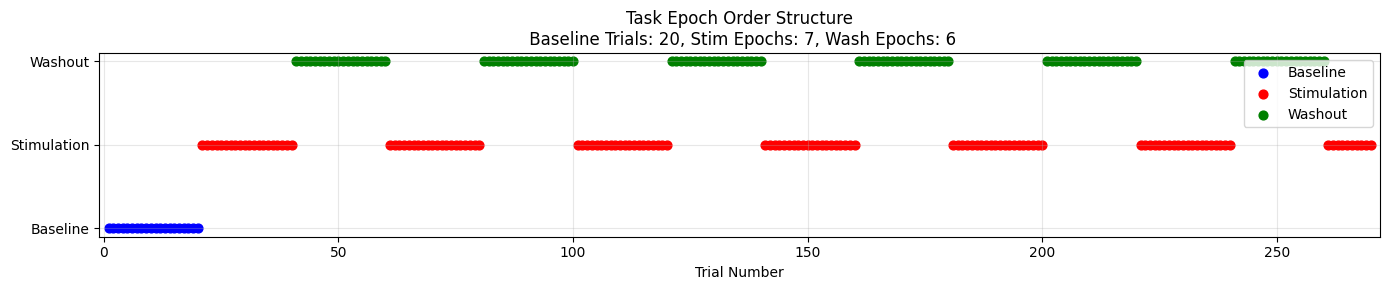

Aligned pca_event_meta saved to: H:\PCA_OUT\Reach15_20260201_session007_NP_Recording_Number02_2026-02-01_18-25-00\bd538bc6b4\processed_data\pca_event_meta_aligned.pkl


,trial_index0,trial_number,start_time,condition,epoch_id,condition_epoch,trial_start_time,start_time_source,start_time_align_method,start_time_align_abs_delta_s,source_event_index
0,0,1,10239.893300,baseline,0,baseline_epoch,10239.893300,all_stimROI_triggers_start_times,nearest_trial_start,0.0,0
1,1,2,10263.343867,baseline,0,baseline_epoch,10263.343867,all_stimROI_triggers_start_times,nearest_trial_start,0.0,1
2,2,3,10285.494367,baseline,0,baseline_epoch,10285.494367,all_stimROI_triggers_start_times,nearest_trial_start,0.0,2
3,3,4,10306.931567,baseline,0,baseline_epoch,10306.931567,all_stimROI_triggers_start_times,nearest_trial_start,0.0,3
4,4,5,10383.171333,baseline,0,baseline_epoch,10383.171333,all_stimROI_triggers_start_times,nearest_trial_start,0.0,4
...,...,...,...,...,...,...,...,...,...,...,...
265,265,266,18693.912033,stimulation,7,stimulation_epoch_7,18693.912033,all_stimROI_triggers_start_times,nearest_trial_start,0.0,265
266,266,267,18714.177167,stimulation,7,stimulation_epoch_7,18714.177167,all_stimROI_triggers_start_times,nearest_trial_start,0.0,266
267,267,268,18743.100500,stimulation,7,stimulation_epoch_7,18743.100500,all_stimROI_triggers_start_times,nearest_trial_start,0.0,267
268,268,269,18764.043367,stimulation,7,stimulation_epoch_7,18764.043367,all_stimROI_triggers_start_times,nearest_trial_start,0.0,268


In [28]:
verify.plot_task_epoch_structure(
    baseline_trials_idx,
    optoicalStim_trials_idx,
    washout_trials_idx,
    trials_are_one_based=True,
    figsize=(14, 3),
    save_plot_path=PLOTS_SAVE_PATH / "epoch_structure.png",
)

DATA_SAVE_PATH = PLOTS_SAVE_PATH / "processed_data"
DATA_SAVE_PATH.mkdir(parents=True, exist_ok=True)
# save out pca_event_meta
(pca_event_meta_aligned).to_pickle(DATA_SAVE_PATH / "pca_event_meta_aligned.pkl")
print("Aligned pca_event_meta saved to:", DATA_SAVE_PATH / "pca_event_meta_aligned.pkl")
pca_event_meta_aligned

#### Build Single Probe Inputs + Scree Plot
Filters units by probe/ROI/KS/brain_region, bins spikes around epoch events, and computes trial-level PCA.


Requested tensor shape=(270, 468, 120) est_mem=0.06 GB
Events: 270 Units: 468
EVR first 5: [0.6158 0.0461 0.0315 0.0192 0.0136]
brain_region: IP, SIM, unknown | align=all_stimROI_triggers_start_times


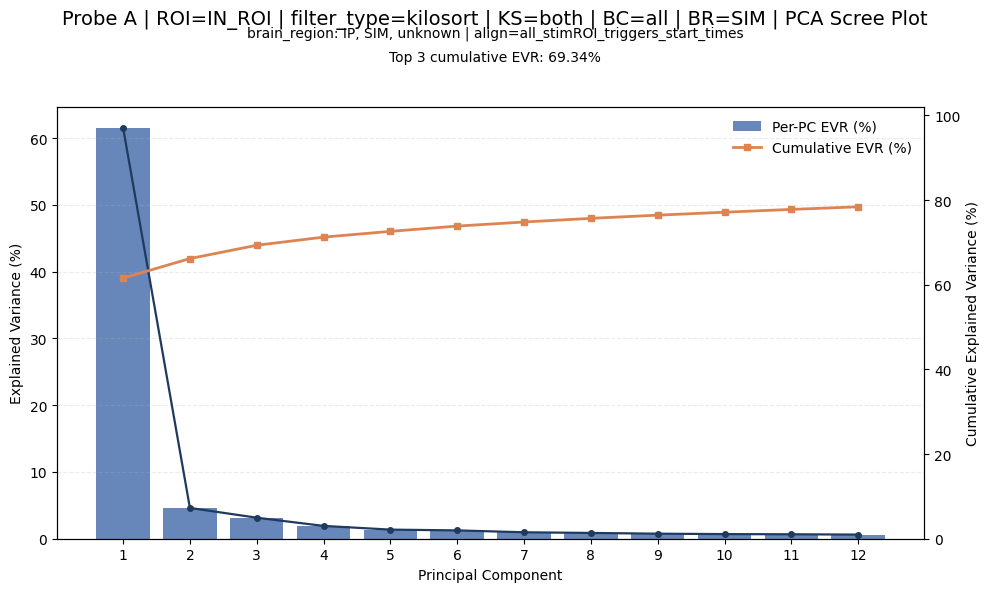

Plots saved to: H:\PCA_OUT\Reach15_20260201_session007_NP_Recording_Number02_2026-02-01_18-25-00\bd538bc6b4


In [18]:
_available_regions_raw = plots._list_probe_brain_regions(
    merged_dic=merged_dic,
    probe=EPOCH_PCA_PROBE,
    roi_filter=EPOCH_PCA_ROI_FILTER,
    kslabel_filter="both",
    bc_label_filter="all",
)
_available_regions = _allowed_regions_only(_available_regions_raw)
if len(_available_regions) == 0:
    raise ValueError(
        f"No allowed brain regions for probe {EPOCH_PCA_PROBE} after filtering. "
        f"Allowed={ALLOWED_BRAIN_REGIONS} | Found={_available_regions_raw}"
    )

if EPOCH_PCA_BRAIN_REGION is None:
    EPOCH_PCA_BRAIN_REGION = _available_regions[0]
else:
    _k = str(EPOCH_PCA_BRAIN_REGION).strip().lower()
    if _k in _allowed_region_map:
        EPOCH_PCA_BRAIN_REGION = _allowed_region_map[_k]

if EPOCH_PCA_BRAIN_REGION not in _available_regions:
    raise ValueError(f"brain_region {EPOCH_PCA_BRAIN_REGION} not available. Available: {_available_regions}")

event_meta_probe, trials_ec, time_ec, Xp_ec, evr_ec = plots.run_epoch_condition_pca_for_probe(
    probe=EPOCH_PCA_PROBE,
    merged_dic=merged_dic,
    event_meta=pca_event_meta_aligned,
    roi_filter=EPOCH_PCA_ROI_FILTER,
    kslabel_filter=EPOCH_PCA_EFFECTIVE_KSLABEL_FILTER,
    bc_label_filter=EPOCH_PCA_EFFECTIVE_BC_LABEL_FILTER,
    include_conditions=EPOCH_PCA_INCLUDE_CONDITIONS,
    n_components=max(3, N_COMPONENTS),
    max_tensor_gb=MAX_TENSOR_GB,
    win_start_s=WINDOW_START_S,
    win_end_s=WINDOW_END_S,
    bin_size_s=BIN_SIZE_S,
    brain_region_filter=EPOCH_PCA_BRAIN_REGION,
)

plot_title = f"Probe {EPOCH_PCA_PROBE} | ROI={EPOCH_PCA_ROI_FILTER} | filter_type={EPOCH_PCA_FILTER_TYPE} | KS={EPOCH_PCA_EFFECTIVE_KSLABEL_FILTER} | BC={EPOCH_PCA_EFFECTIVE_BC_LABEL_FILTER} | BR={EPOCH_PCA_BRAIN_REGION}"
brain_region_subtitle = plots.probe_brain_region_label(
    merged_dic=merged_dic,
    probe=EPOCH_PCA_PROBE,
    roi_filter=EPOCH_PCA_ROI_FILTER,
    kslabel_filter=EPOCH_PCA_EFFECTIVE_KSLABEL_FILTER,
    bc_label_filter=EPOCH_PCA_EFFECTIVE_BC_LABEL_FILTER,
)
brain_region_subtitle = f"{brain_region_subtitle} | align={EVENT_TIME_ALIGN_TO}"

print("Events:", len(event_meta_probe), "Units:", trials_ec.shape[1])
print("EVR first 5:", np.round(evr_ec[:5], 4))
print(brain_region_subtitle)

plots.plot_pca_scree(
    evr=evr_ec,
    title_prefix=plot_title,
    subtitle=brain_region_subtitle,
    probe=EPOCH_PCA_PROBE,
    brain_region=EPOCH_PCA_BRAIN_REGION,
    run_label="epoch_condition",
    save_root=PLOTS_SAVE_PATH,
    show_plots=SHOW_PLOTS_SINGLE,
)

print('Plots saved to:', PLOTS_SAVE_PATH)

## Group 1: Base Trial-Level Epoch Plot Set
Creates one large figure with 3 subplots:
- 2D PC1/PC2 scatter
- 3D PC1/PC2/PC3 scatter
- 3D PC1/PC2/Time


In [19]:
print('You are about to run PCA on the following selection:')
EPOCH_PCA_PROBE,EPOCH_PCA_BRAIN_REGION, EPOCH_PCA_ROI_FILTER, EPOCH_PCA_FILTER_TYPE, EPOCH_PCA_EFFECTIVE_KSLABEL_FILTER, EPOCH_PCA_EFFECTIVE_BC_LABEL_FILTER

def check_PCA_varibles(EPOCH_PCA_PROBE,EPOCH_PCA_BRAIN_REGION, EPOCH_PCA_ROI_FILTER, EPOCH_PCA_FILTER_TYPE, EPOCH_PCA_EFFECTIVE_KSLABEL_FILTER, EPOCH_PCA_EFFECTIVE_BC_LABEL_FILTER):
    print("\n========== PCA Variable Overview Summary ==========")
    print(f"Probe: {EPOCH_PCA_PROBE}")
    print(f"Filter type: {EPOCH_PCA_FILTER_TYPE}")
    print(f"Effective KS filter: {EPOCH_PCA_EFFECTIVE_KSLABEL_FILTER}")
    print(f"Effective BC filter: {EPOCH_PCA_EFFECTIVE_BC_LABEL_FILTER}")
    print(f"Event aligned to: {EVENT_TIME_ALIGN_TO}")
    print(f"Alignment count mode: {_count_mode}")
    print(f"Event source count: {EVENT_TIME_SOURCE_COUNT}")
    print(f"Total aligned events: {len(pca_event_meta_aligned)}")
    print(f"Brain regions ({len(_summary_regions)}): {_summary_regions}")
    print(f"Selected brain region: {_summary_selected_br}")
    _units_df_cfg = plots.pca_get_probe_units_df(
        merged_dic=merged_dic,
        probe=EPOCH_PCA_PROBE,
        roi_filter=EPOCH_PCA_ROI_FILTER,
        kslabel_filter=EPOCH_PCA_EFFECTIVE_KSLABEL_FILTER,
        bc_label_filter=EPOCH_PCA_EFFECTIVE_BC_LABEL_FILTER,
    )
    _norm_br = getattr(plots, "_normalize_brain_region_value", lambda x: str(x).strip())
    _br_counts = {}
    if ("brain_region" in _units_df_cfg.columns) and (len(_units_df_cfg) > 0):
        for _v in _units_df_cfg["brain_region"].tolist():
            if _v is None:
                continue
            _name = str(_norm_br(_v)).strip()
            if _name == "" or _name.lower() == "nan":
                continue
            _br_counts[_name] = int(_br_counts.get(_name, 0)) + 1
    _br_print_order = list(ALLOWED_BRAIN_REGIONS)
    for _k in sorted(_br_counts.keys()):
        if _k not in _br_print_order:
            _br_print_order.append(_k)
    print("Unit counts by brain region (current filters):")
    for _br in _br_print_order:
        print(f"  {_br}: {int(_br_counts.get(_br, 0))}")
    print(f"Total units after current filters: {len(_units_df_cfg)}")
    print("======================================\n")

check_PCA_varibles(EPOCH_PCA_PROBE,EPOCH_PCA_BRAIN_REGION, EPOCH_PCA_ROI_FILTER, EPOCH_PCA_FILTER_TYPE, EPOCH_PCA_EFFECTIVE_KSLABEL_FILTER, EPOCH_PCA_EFFECTIVE_BC_LABEL_FILTER)

You are about to run PCA on the following selection:

========== PCA Variable Overview Summary ==========
Probe: A
Filter type: kilosort
Effective KS filter: both
Effective BC filter: all
Event aligned to: all_stimROI_triggers_start_times
Alignment count mode: use_all_source_events
Event source count: 270
Total aligned events: 270
Brain regions (2): ['SIM', 'IP']
Selected brain region: SIM
Unit counts by brain region (current filters):
  PG: 0
  SIM: 468
  IP: 72
  VaL: 0
  MoP: 0
  SnR: 0
  RN: 0
  unknown: 14
Total units after current filters: 554



c:\Users\user\Documents\github\PCA_on_neural_data\master_02\pca_plotting.py:3009: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.86, 0.9])


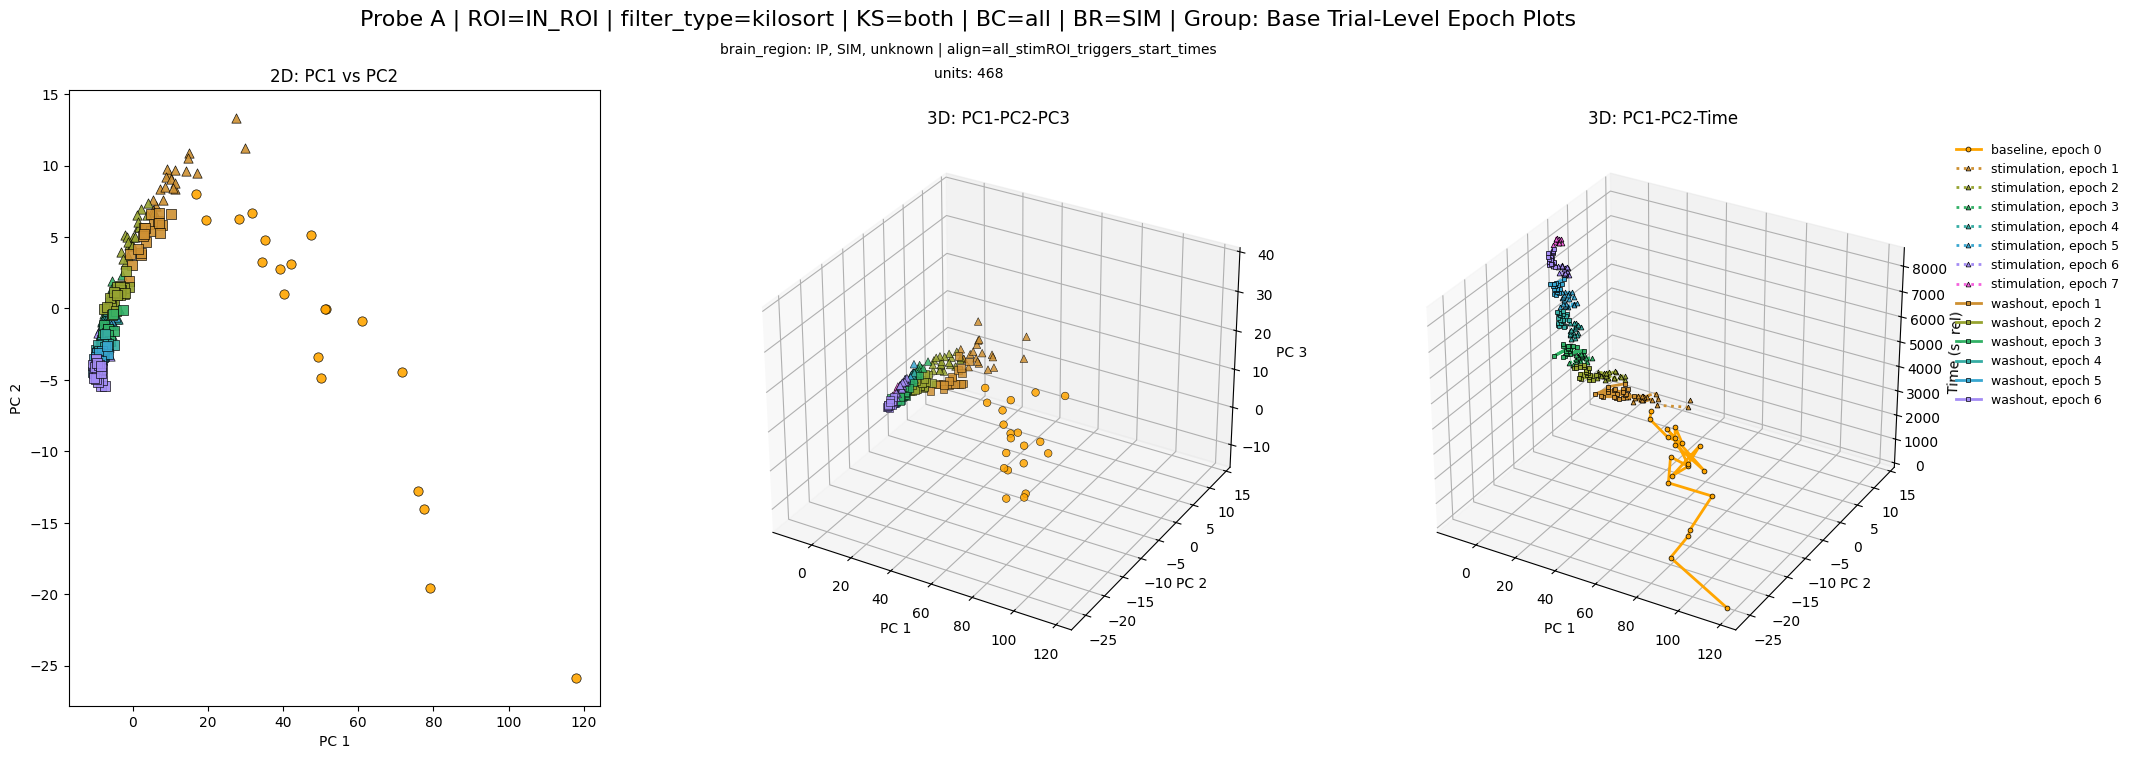

In [20]:
plots.set_epoch_plot_style(
    color_mode=PLOT_COLOR_MODE,
    stimulation_linestyle=STIMULATION_LINESTYLE,
    washout_linestyle=WASHOUT_LINESTYLE,
    baseline_linestyle=BASELINE_LINESTYLE,
    baseline_color=BASELINE_COLOR,
    mode3_base_color=MODE3_BASE_COLOR,
    mode3_stimulation_color=MODE3_STIMULATION_COLOR,
    mode3_washout_color=MODE3_WASHOUT_COLOR,
    mode3_baseline_color=MODE3_BASELINE_COLOR,
    mode3_highlight_color=MODE3_HIGHLIGHT_COLOR,
    mode3_highlight_window_s=MODE3_HIGHLIGHT_WINDOW_S,
)

plots.plot_epoch_condition_group_base_trial(
    Xp=Xp_ec,
    event_meta=event_meta_probe,
    title_prefix=plot_title,
    subtitle=brain_region_subtitle,
    probe=EPOCH_PCA_PROBE,
    brain_region=EPOCH_PCA_BRAIN_REGION,
    time_col="start_time",
    n_units=trials_ec.shape[1],
    save_root=PLOTS_SAVE_PATH,
    show_plots=SHOW_PLOTS_SINGLE,
)


## Group 2: Epoch-Mean Plot Set
Creates one large figure with 4 subplots:
- 2D epoch-mean
- 3D epoch-mean
- 3D epoch-mean PC1/PC2/Time points
- 3D epoch-mean PC1/PC2/Time lines


c:\Users\user\Documents\github\PCA_on_neural_data\master_02\pca_plotting.py:3132: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.86, 0.92])


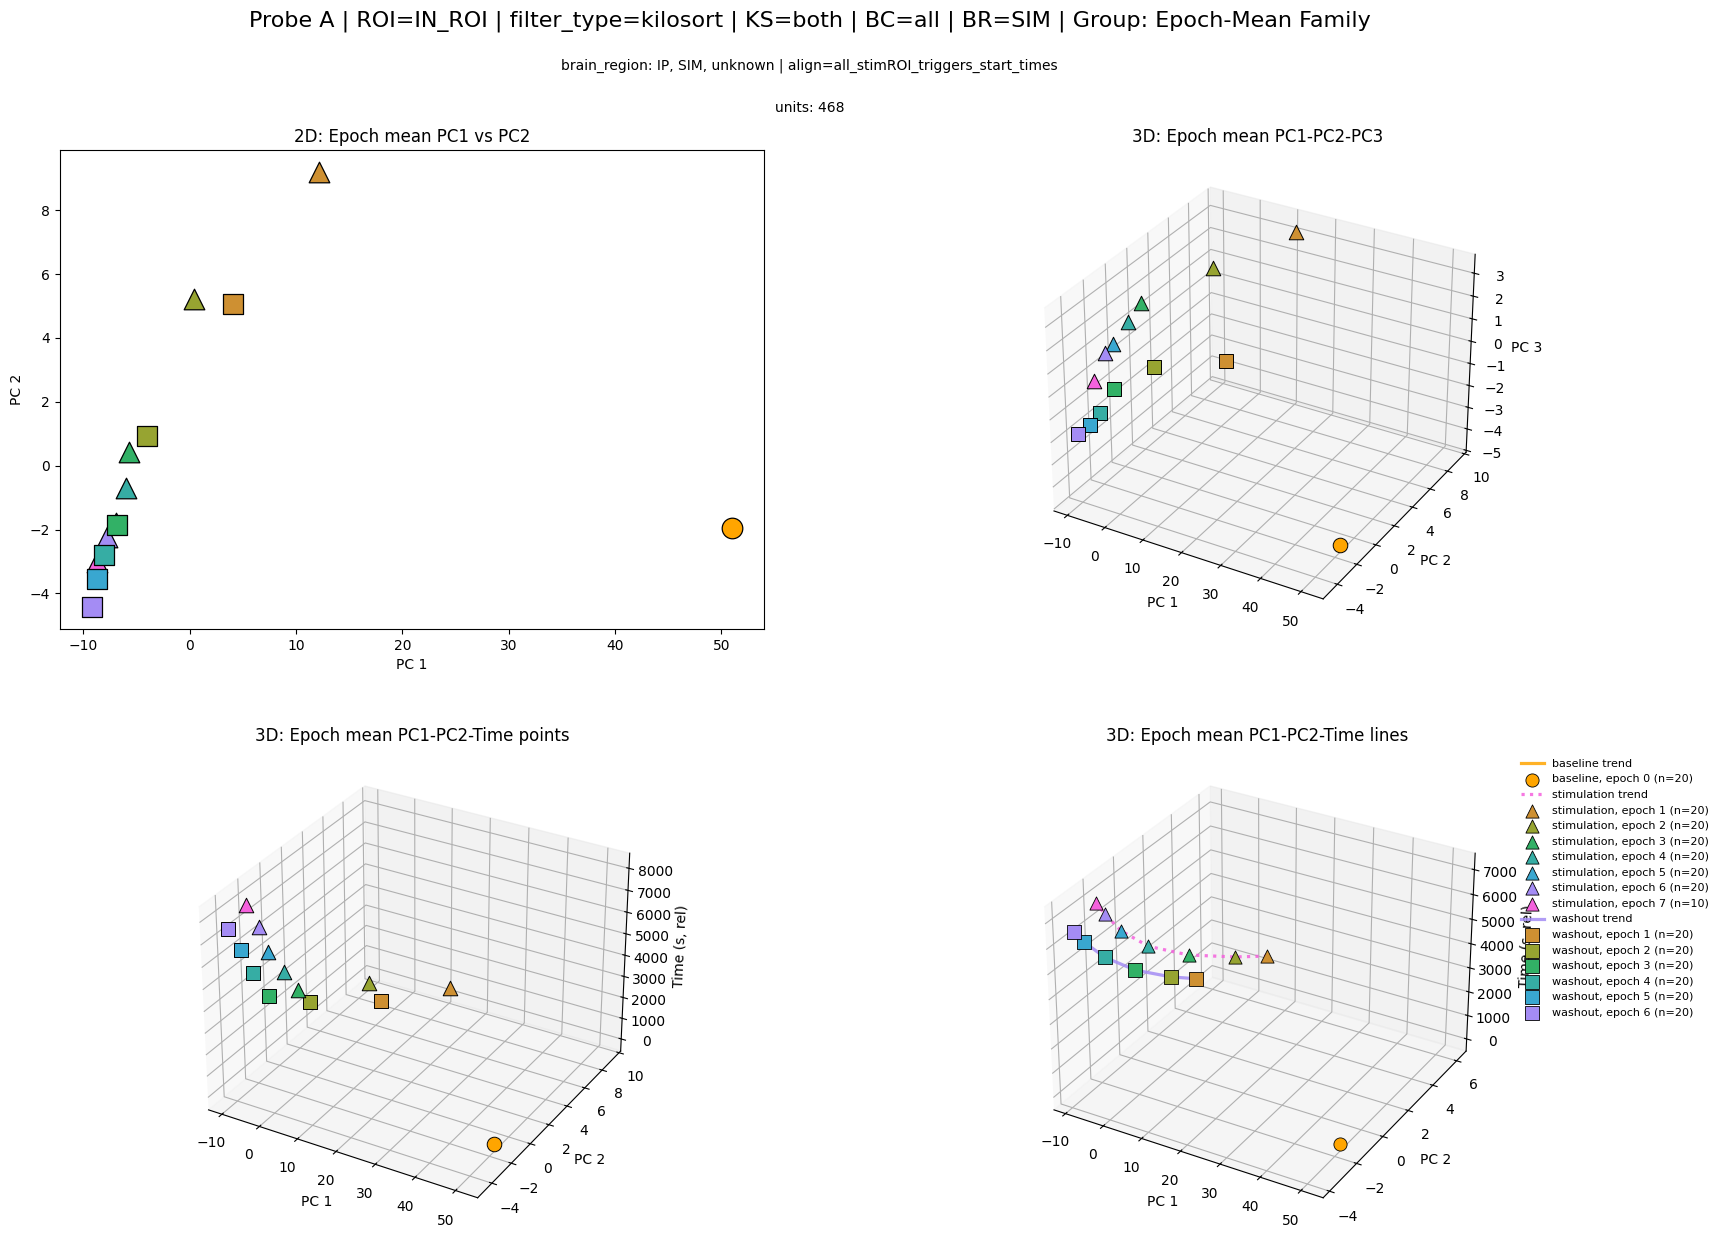

In [21]:
plots.plot_epoch_condition_group_epochmean(
    Xp=Xp_ec,
    event_meta=event_meta_probe,
    title_prefix=plot_title,
    subtitle=brain_region_subtitle,
    probe=EPOCH_PCA_PROBE,
    brain_region=EPOCH_PCA_BRAIN_REGION,
    smooth_sigma=SMOOTH_SIGMA,
    n_units=trials_ec.shape[1],
    save_root=PLOTS_SAVE_PATH,
    show_plots=SHOW_PLOTS_SINGLE,
)


## Group 3: Per-Trial Time-Bin Plot Set
Creates one large figure with 3 subplots from trial-level time-bin PCA trajectories:
- 2D lines
- 3D PC1/PC2/PC3 lines
- 3D PC1/PC2/Time lines


Trial-time PCA EVR first 5: [0.1061 0.0366 0.0155 0.0119 0.0104]


c:\Users\user\Documents\github\PCA_on_neural_data\master_02\pca_plotting.py:3264: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.86, 0.9])


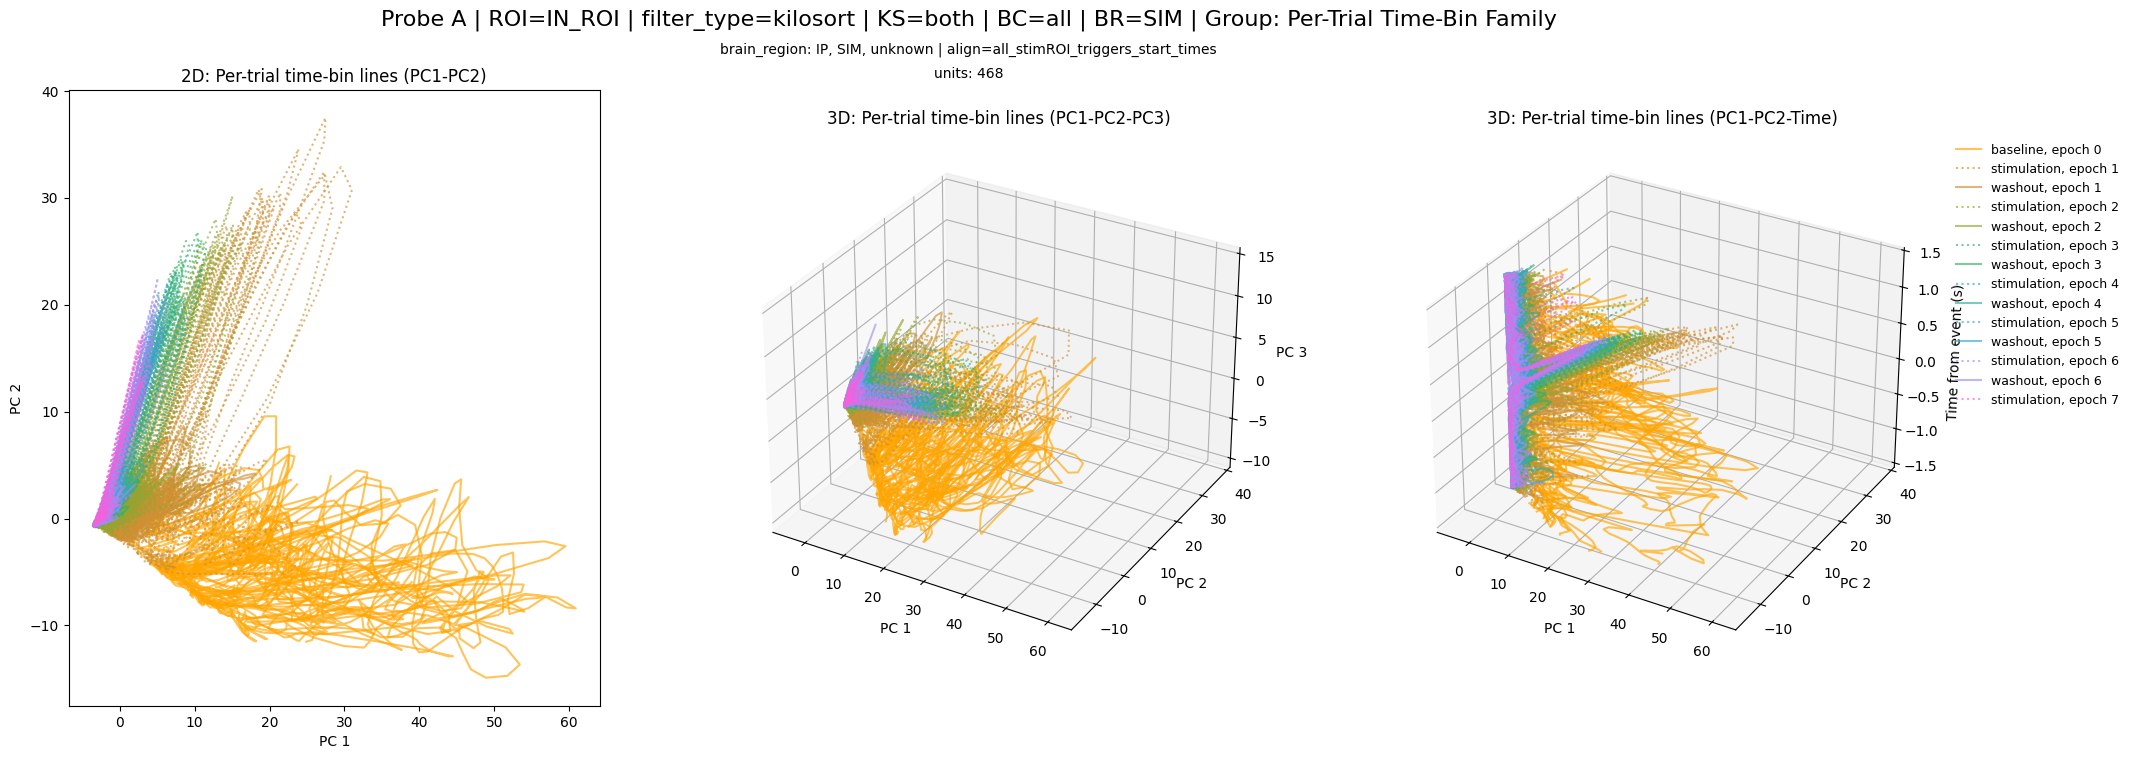

In [22]:
trial_time_scores, trial_time_evr = plots.pca_trial_timebin_scores(
    trials=trials_ec,
    n_components=max(3, N_COMPONENTS),
)
print("Trial-time PCA EVR first 5:", np.round(trial_time_evr[:5], 4))

plots.plot_epoch_condition_group_trial_time(
    trial_time_scores=trial_time_scores,
    event_meta=event_meta_probe,
    bin_time=time_ec,
    title_prefix=plot_title,
    subtitle=brain_region_subtitle,
    probe=EPOCH_PCA_PROBE,
    brain_region=EPOCH_PCA_BRAIN_REGION,
    smooth_sigma=SMOOTH_SIGMA,
    n_units=trials_ec.shape[1],
    save_root=PLOTS_SAVE_PATH,
    show_plots=SHOW_PLOTS_SINGLE,
)


## Group 4: One-Line-Per-Epoch Population Plot Set
Creates one large figure with 3 subplots from epoch-averaged population trajectories:
- 2D lines
- 3D PC1/PC2/PC3 lines
- 3D PC1/PC2/Time lines


Epoch-population PCA EVR first 5: [0.3814 0.1068 0.0269 0.0194 0.0141]


c:\Users\user\Documents\github\PCA_on_neural_data\master_02\pca_plotting.py:3394: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.86, 0.9])


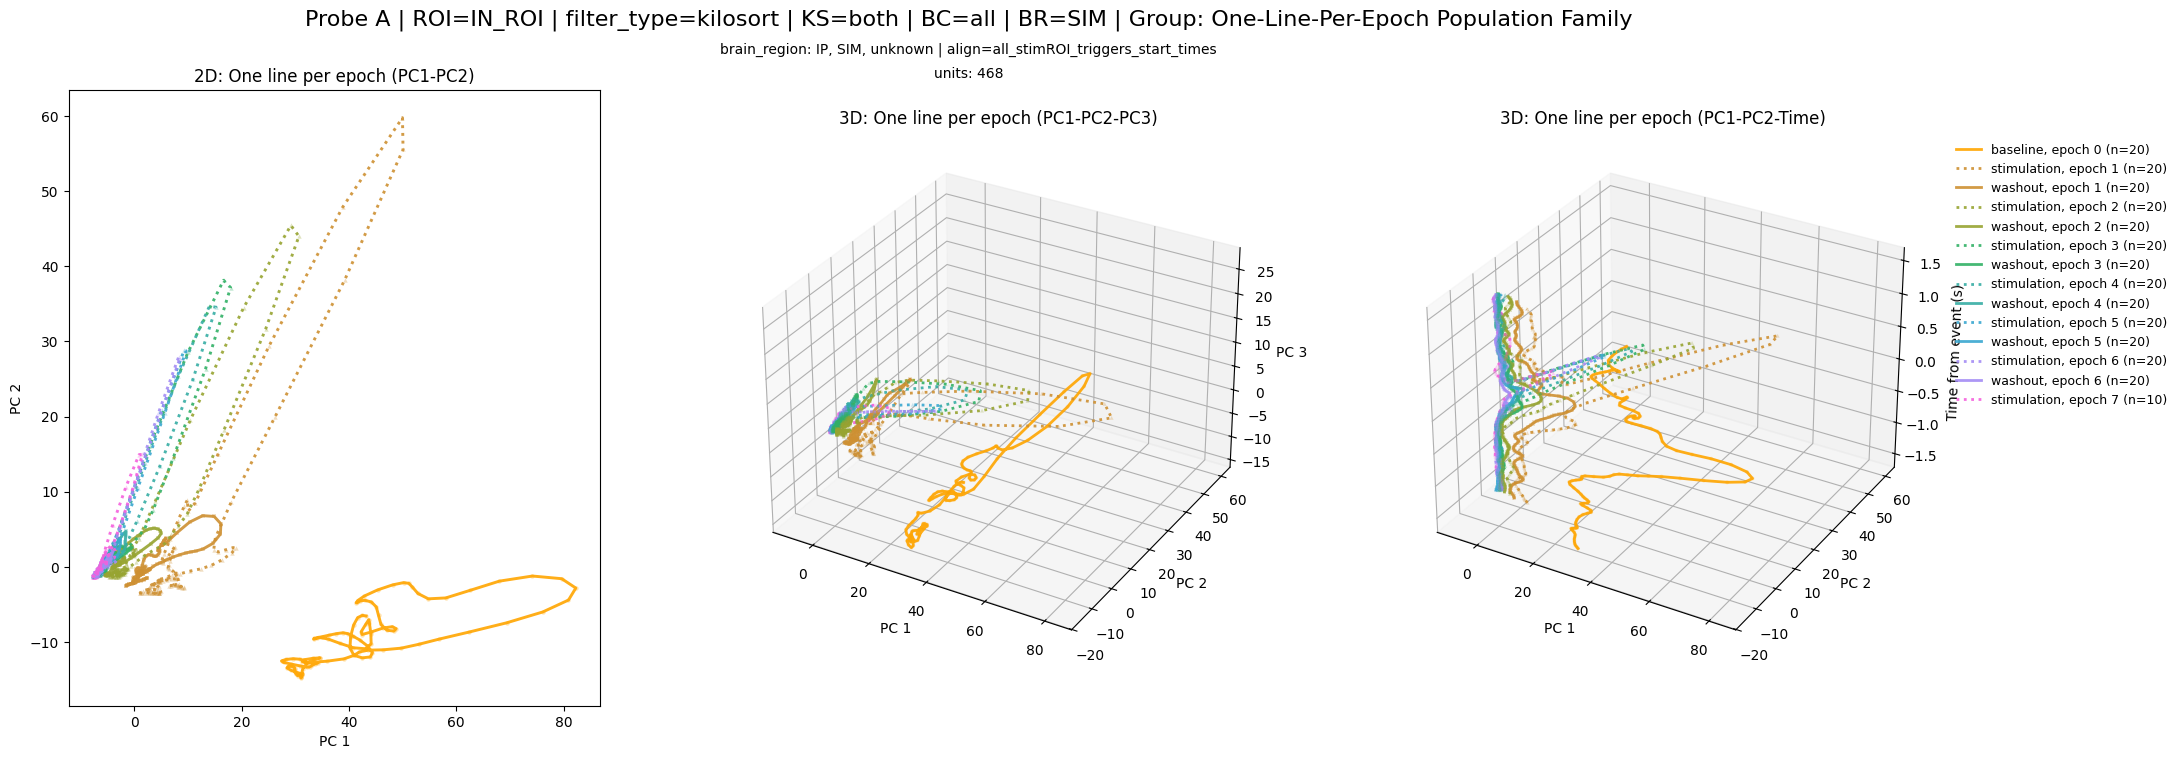

In [23]:
epoch_info_df, epoch_traj, epoch_evr = plots.pca_epoch_population_timebin_trajectories(
    trials=trials_ec,
    event_meta=event_meta_probe,
    n_components=max(3, N_COMPONENTS),
)
print("Epoch-population PCA EVR first 5:", np.round(epoch_evr[:5], 4))

plots.plot_epoch_condition_group_epoch_population(
    epoch_info_df=epoch_info_df,
    epoch_traj=epoch_traj,
    bin_time=time_ec,
    title_prefix=plot_title,
    subtitle=brain_region_subtitle,
    probe=EPOCH_PCA_PROBE,
    brain_region=EPOCH_PCA_BRAIN_REGION,
    smooth_sigma=SMOOTH_SIGMA,
    n_units=trials_ec.shape[1],
    save_root=PLOTS_SAVE_PATH,
    show_plots=SHOW_PLOTS_SINGLE,
)


## Optional Legacy Individual Plot Calls
These are intentionally disabled to keep grouped workflow as default.


In [24]:
print("Grouped workflow is active. Individual legacy calls are disabled in this notebook version.")


Grouped workflow is active. Individual legacy calls are disabled in this notebook version.


## Optional Legacy Individual Plot Calls (continued)


In [25]:
print("Grouped workflow is active. Individual legacy calls are disabled in this notebook version.")


Grouped workflow is active. Individual legacy calls are disabled in this notebook version.


#### ==============================================================================================================================================================================================================================
## Batch PCA Run Config
#### ==============================================================================================================================================================================================================================


### 3 different plotting modes. all based on the coloring of the lines

Mode #1 = (Normal) where stimulation epoch #1 and Washout Epoch #1 share a color. same with Stimulation Epoch #2 and Washout Epoch #2

Mode #2 = (stim blue + washout red) All stimulation trials are BLUE and all washout trials are GREEN. There is a graident for each epoch, epoch #1 is lighter Blue or Green than Epoch #2 for example

Mode #3 = (Gray with 0-500ms green) All lines are GRAY, with stimultion trials remaining dotted, and wasout trials remaning solid lines. However, from event start_time to +500ms all lines are colored green. this should show the reach moment.  

#### How to select plotting mode:
 - PLOT_COLOR_MODE = 3  # 1=regular shared epoch colors, 2=stim blue + wash red gradients, 3=gray base + condition highlight for first MODE3_HIGHLIGHT_WINDOW_S seconds


In [29]:
DATA_SAVE_PATH = PLOTS_SAVE_PATH / "processed_data"
DATA_SAVE_PATH.mkdir(parents=True, exist_ok=True)
# save out pca_event_meta
(pca_event_meta_aligned).to_pickle(DATA_SAVE_PATH / "pca_event_meta_aligned.pkl")
print("Aligned pca_event_meta saved to:", DATA_SAVE_PATH / "pca_event_meta_aligned.pkl")
pca_event_meta_aligned

Aligned pca_event_meta saved to: H:\PCA_OUT\Reach15_20260201_session007_NP_Recording_Number02_2026-02-01_18-25-00\bd538bc6b4\processed_data\pca_event_meta_aligned.pkl


,trial_index0,trial_number,start_time,condition,epoch_id,condition_epoch,trial_start_time,start_time_source,start_time_align_method,start_time_align_abs_delta_s,source_event_index
0,0,1,10239.893300,baseline,0,baseline_epoch,10239.893300,all_stimROI_triggers_start_times,nearest_trial_start,0.0,0
1,1,2,10263.343867,baseline,0,baseline_epoch,10263.343867,all_stimROI_triggers_start_times,nearest_trial_start,0.0,1
2,2,3,10285.494367,baseline,0,baseline_epoch,10285.494367,all_stimROI_triggers_start_times,nearest_trial_start,0.0,2
3,3,4,10306.931567,baseline,0,baseline_epoch,10306.931567,all_stimROI_triggers_start_times,nearest_trial_start,0.0,3
4,4,5,10383.171333,baseline,0,baseline_epoch,10383.171333,all_stimROI_triggers_start_times,nearest_trial_start,0.0,4
...,...,...,...,...,...,...,...,...,...,...,...
265,265,266,18693.912033,stimulation,7,stimulation_epoch_7,18693.912033,all_stimROI_triggers_start_times,nearest_trial_start,0.0,265
266,266,267,18714.177167,stimulation,7,stimulation_epoch_7,18714.177167,all_stimROI_triggers_start_times,nearest_trial_start,0.0,266
267,267,268,18743.100500,stimulation,7,stimulation_epoch_7,18743.100500,all_stimROI_triggers_start_times,nearest_trial_start,0.0,267
268,268,269,18764.043367,stimulation,7,stimulation_epoch_7,18764.043367,all_stimROI_triggers_start_times,nearest_trial_start,0.0,268


In [30]:
reachInit_stimROI = pca_event_meta.condition_epoch
print("reachInit_stimROI value counts:\n", reachInit_stimROI.value_counts())


reachInit_stimROI value counts:
 condition_epoch
baseline_epoch         20
stimulation_epoch_1    20
washout_epoch_1        20
stimulation_epoch_2    20
washout_epoch_2        20
stimulation_epoch_3    20
washout_epoch_3        20
stimulation_epoch_4    20
washout_epoch_4        20
stimulation_epoch_5    20
washout_epoch_5        20
stimulation_epoch_6    20
washout_epoch_6        20
stimulation_epoch_7    10
Name: count, dtype: int64


Verify PCA parameters being used

In [31]:
# ================================= MODIFY THE 5 PARAMETER SETS ========================================

# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
# SET #1: Select probe and unit filtering (Bombcell or Kilosort) for epoch PCA analysis 
# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
EPOCH_PCA_PROBE = "A"
EPOCH_PCA_BRAIN_REGION = None   # None => first available region after filtering
EPOCH_PCA_ROI_FILTER = "IN_ROI"  # None, "IN_ROI", "OUT_ROI"
EPOCH_PCA_KSLABEL_FILTER = "both"  # "both", "good", "mua"
EPOCH_PCA_BC_LABEL_FILTER = ["GOOD", "MUA"]  # "all" or subset like "GOOD" / ["GOOD", "MUA"]
EPOCH_PCA_INCLUDE_CONDITIONS = ["baseline", "stimulation", "washout"]
EPOCH_PCA_FILTER_TYPE = "kilosort"  # "bombcell" or "kilosort"


# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
# SET #2: Pick which event to align PCA windows to 
# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
# Options: 'start_time', 'tone1_start_times', 'tone2_start_times', 'stimROI_start_times', 'optical_start_times', 'all_stimROI_triggers_start_times', 'custom_event_start_times'
EVENT_TIME_ALIGN_TO = "all_stimROI_triggers_start_times"
# Optional: set this to any future event array and use EVENT_TIME_ALIGN_TO = "custom_event_start_times"
CUSTOM_EVENT_START_TIMES = None
custom_event_start_times = CUSTOM_EVENT_START_TIMES
# 'index' | 'nearest' | 'index_then_nearest'
EVENT_TIME_ALIGN_MISMATCH = "index_then_nearest"
# 'preserve_aligned_rows' keeps aligned trial rows; 'match_source_count' keeps strict index rows; 'use_all_source_events' maps every source event to trial windows.
EVENT_TIME_ALIGN_COUNT_MODE = "use_all_source_events"
# None disables cutoff. Otherwise, nearest matches farther than this are dropped.
EVENT_TIME_ALIGN_MAX_DELTA_S = None
EVENT_TIME_DROP_UNMATCHED = True
# If True, enforce source-specific condition consistency after alignment.
# Example: stimROI_start_times should map to stimulation rows only.
EVENT_TIME_ENFORCE_SOURCE_CONDITION = False

# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
# SET #3: Sekect the plotting style 
# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
PLOT_COLOR_MODE = 1 # 1=regular shared epoch colors, 2=stim blue + wash red gradients, 3=gray base + condition highlight for first MODE3_HIGHLIGHT_WINDOW_S seconds
STIMULATION_LINESTYLE = ":"
WASHOUT_LINESTYLE = "-"
BASELINE_LINESTYLE = "-"
BASELINE_COLOR = "orange"
# Mode 3: Select the highlight window for each epoch (e.g. 0-500ms) and the color to use for that highlight, while the rest of the epoch is a more neutral color
MODE3_HIGHLIGHT_WINDOW_S = 0.5
MODE3_HIGHLIGHT_COLOR = "green"  # fallback only for unknown condition labels
# Mode 3: Select the base color for the non-highlight portion of each epoch
MODE3_BASE_COLOR = "gray"
# Mode 3: Select Highlight color for 0-500ms for each epoch 
MODE3_STIMULATION_COLOR = "purple"
MODE3_WASHOUT_COLOR = "green"
MODE3_BASELINE_COLOR = "orange"

# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
# SET #4: Define constants and parameters for PCA analysis and plotting 
# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
WINDOW_START_S = -1.5
WINDOW_END_S = 1.5
BIN_SIZE_S = 0.025
MAX_TENSOR_GB = 8.0
N_COMPONENTS = 12
SMOOTH_SIGMA = 1.5

# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
# SET #5: Sekect the elevation and azimuth for 3D PCA trajectory plots for each probe/region as desired 
# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
REGION_PANEL_PC123_ELEV = 25
REGION_PANEL_PC123_AZIM = -60
REGION_PANEL_PC12TIME_ELEV = 20
REGION_PANEL_PC12TIME_AZIM = -60

# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
# SET #6: Parameters for the "by region across probes" panel plot at the end of the notebook. This is optional and can be ignored if not using that section.
# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
RUN_REGION_ORDERED_COMPOSITES = True
REGION_PANEL_ORDER = ["PG", "SIM", "IP", "VaL", "MoP", "SnR", "RN"]
REGION_PANEL_FAMILIES = ["base_trial", "epochmean", "trial_time", "epoch_population"]
REGION_PANEL_COLS = 1
REGION_PANEL_SAVE_SUBDIR = "Grouped_ByRegionAcrossProbes"
REGION_PANEL_INCLUDE_UNLISTED = True


# ================================= END OF MODIFY THE 5 PARAMETER SETS ========================================





###### ================= DO NOT EDIT BELOW UNLESS YOU KNOW WHAT YOU ARE CHANGING WILL DO ================= ######
_epoch_cfg = prep.configure_epoch_pca_runner(
    plots=plots,
    merged_dic=merged_dic,
    pca_event_meta=pca_event_meta,
    tone1_start_times=tone1_start_times,
    tone2_start_times=tone2_start_times,
    stimROI_start_times=stimROI_start_times,
    optical_start_times=optical_start_times,
    all_stimROI_triggers_start_times=all_stimROI_triggers_start_times,
    custom_event_start_times=CUSTOM_EVENT_START_TIMES,
    EPOCH_PCA_PROBE=EPOCH_PCA_PROBE,
    EPOCH_PCA_BRAIN_REGION=EPOCH_PCA_BRAIN_REGION,
    EPOCH_PCA_ROI_FILTER=EPOCH_PCA_ROI_FILTER,
    EPOCH_PCA_KSLABEL_FILTER=EPOCH_PCA_KSLABEL_FILTER,
    EPOCH_PCA_BC_LABEL_FILTER=EPOCH_PCA_BC_LABEL_FILTER,
    EPOCH_PCA_FILTER_TYPE=EPOCH_PCA_FILTER_TYPE,
    EVENT_TIME_ALIGN_TO=EVENT_TIME_ALIGN_TO,
    EVENT_TIME_ALIGN_MISMATCH=EVENT_TIME_ALIGN_MISMATCH,
    EVENT_TIME_ALIGN_COUNT_MODE=EVENT_TIME_ALIGN_COUNT_MODE,
    EVENT_TIME_ALIGN_MAX_DELTA_S=EVENT_TIME_ALIGN_MAX_DELTA_S,
    EVENT_TIME_DROP_UNMATCHED=EVENT_TIME_DROP_UNMATCHED,
    EVENT_TIME_ENFORCE_SOURCE_CONDITION=EVENT_TIME_ENFORCE_SOURCE_CONDITION,
    PLOT_COLOR_MODE=PLOT_COLOR_MODE,
    STIMULATION_LINESTYLE=STIMULATION_LINESTYLE,
    WASHOUT_LINESTYLE=WASHOUT_LINESTYLE,
    BASELINE_LINESTYLE=BASELINE_LINESTYLE,
    BASELINE_COLOR=BASELINE_COLOR,
    MODE3_BASE_COLOR=MODE3_BASE_COLOR,
    MODE3_STIMULATION_COLOR=MODE3_STIMULATION_COLOR,
    MODE3_WASHOUT_COLOR=MODE3_WASHOUT_COLOR,
    MODE3_BASELINE_COLOR=MODE3_BASELINE_COLOR,
    MODE3_HIGHLIGHT_COLOR=MODE3_HIGHLIGHT_COLOR,
    MODE3_HIGHLIGHT_WINDOW_S=MODE3_HIGHLIGHT_WINDOW_S,
    REGION_PANEL_PC123_ELEV=REGION_PANEL_PC123_ELEV,
    REGION_PANEL_PC123_AZIM=REGION_PANEL_PC123_AZIM,
    REGION_PANEL_PC12TIME_ELEV=REGION_PANEL_PC12TIME_ELEV,
    REGION_PANEL_PC12TIME_AZIM=REGION_PANEL_PC12TIME_AZIM,
    PLOTS_SAVE_ROOT=PLOTS_SAVE_ROOT,
)
EPOCH_PCA_EFFECTIVE_KSLABEL_FILTER = _epoch_cfg["EPOCH_PCA_EFFECTIVE_KSLABEL_FILTER"]
EPOCH_PCA_EFFECTIVE_BC_LABEL_FILTER = _epoch_cfg["EPOCH_PCA_EFFECTIVE_BC_LABEL_FILTER"]
save_filter_tag = _epoch_cfg["save_filter_tag"]
ALLOWED_BRAIN_REGIONS = _epoch_cfg["ALLOWED_BRAIN_REGIONS"]
_allowed_region_map = {r.lower(): r for r in ALLOWED_BRAIN_REGIONS}
_allowed_regions_only = _epoch_cfg["_allowed_regions_only"]
pca_event_meta_aligned = _epoch_cfg["pca_event_meta_aligned"]
EVENT_TIME_ALIGN_REPORT = _epoch_cfg["EVENT_TIME_ALIGN_REPORT"]
EVENT_TIME_SOURCE_COUNT = _epoch_cfg["EVENT_TIME_SOURCE_COUNT"]
_count_mode = _epoch_cfg["_count_mode"]
_summary_regions = _epoch_cfg["_summary_regions"]
_summary_selected_br = _epoch_cfg["_summary_selected_br"]
EVENT_TIME_ALIGN_FOLDER = _epoch_cfg["EVENT_TIME_ALIGN_FOLDER"]
ANGLE_FOLDER_TAG = _epoch_cfg["ANGLE_FOLDER_TAG"]
PLOTS_SAVE_PATH = _epoch_cfg["PLOTS_SAVE_PATH"]
SHOW_PLOTS_SINGLE = _epoch_cfg["SHOW_PLOTS_SINGLE"]
SHOW_PLOTS_BATCH = _epoch_cfg["SHOW_PLOTS_BATCH"]
# Short/flat save layout with run metadata (Windows-safe)
import json
import hashlib
from datetime import datetime

_SHORT_ROOT = Path(FULL_SESSION_PATH.anchor) / "PCA_OUT" / str(SESSION_NAME)
_run_key = {
    "session": str(SESSION_NAME),
    "probe": str(EPOCH_PCA_PROBE),
    "align_to": str(EVENT_TIME_ALIGN_TO),
    "filter_type": str(EPOCH_PCA_FILTER_TYPE),
    "plot_color_mode": int(PLOT_COLOR_MODE),
}
_run_id = hashlib.sha1(json.dumps(_run_key, sort_keys=True).encode("utf-8")).hexdigest()[:10]
PLOTS_SAVE_PATH = _SHORT_ROOT / _run_id
PLOTS_SAVE_PATH.mkdir(parents=True, exist_ok=True)

_run_meta = {
    "created_at": datetime.now().isoformat(),
    "session_name": str(SESSION_NAME),
    "full_session_path": str(FULL_SESSION_PATH),
    "plot_save_path": str(PLOTS_SAVE_PATH),
    "probe": str(EPOCH_PCA_PROBE),
    "brain_region": None if EPOCH_PCA_BRAIN_REGION is None else str(EPOCH_PCA_BRAIN_REGION),
    "roi_filter": None if EPOCH_PCA_ROI_FILTER is None else str(EPOCH_PCA_ROI_FILTER),
    "filter_type": str(EPOCH_PCA_FILTER_TYPE),
    "ks_filter": str(EPOCH_PCA_EFFECTIVE_KSLABEL_FILTER),
    "bc_filter": str(EPOCH_PCA_EFFECTIVE_BC_LABEL_FILTER),
    "event_align_to": str(EVENT_TIME_ALIGN_TO),
    "event_align_count_mode": str(EVENT_TIME_ALIGN_COUNT_MODE),
    "event_align_mismatch": str(EVENT_TIME_ALIGN_MISMATCH),
    "event_source_count": int(EVENT_TIME_SOURCE_COUNT),
    "aligned_event_count": int(len(pca_event_meta_aligned)),
    "window_start_s": float(WINDOW_START_S),
    "window_end_s": float(WINDOW_END_S),
    "bin_size_s": float(BIN_SIZE_S),
    "n_components": int(N_COMPONENTS),
    "plot_color_mode": int(PLOT_COLOR_MODE),
}
(PLOTS_SAVE_PATH / "run_metadata.json").write_text(json.dumps(_run_meta, indent=2), encoding="utf-8")
print("short save path:", PLOTS_SAVE_PATH)
print("metadata file:", PLOTS_SAVE_PATH / "run_metadata.json")

Filter type=kilosort | effective KS=both | effective BC=all
event-time alignment: {'source': 'all_stimROI_triggers_start_times', 'method': 'index_then_nearest', 'used_index': True, 'input_rows': 270, 'output_rows': 270, 'unmatched_rows': 0, 'count_mode': 'use_all_source_events', 'source_count': 270, 'output_rows_before_count_mode': 270, 'output_rows_after_count_mode': 270, 'source_condition_filter': None, 'output_rows_before_source_condition_filter': 270, 'output_rows_after_source_condition_filter': 270, 'output_rows_after_source_condition_only': 270, 'expanded_from_source': True, 'expand_report': {'source': 'all_stimROI_triggers_start_times', 'method': 'nearest_trial_start', 'trial_rows_input': 270, 'source_count_input': 270, 'source_count_finite': 270, 'source_count_non_finite': 0, 'dropped_before_first_trial': 0, 'output_rows': 270, 'sorted_source_times': False}, 'stim_sequence_source_count': 0, 'stim_sequence_stimulation_rows': 0, 'stim_sequence_rows_mapped': 0}

========== PCA Plo

### This the Dataframe that will be used for all the PCA plotting functions.
- It has been aligned to the selected event time
- and filtered according to the selected probe, brain region, and unit filters. 
- Each row is one trial/epoch, and it includes columns for the trial metadata as well as the aligned event time.

In [33]:
pca_event_meta_aligned[0:3]

,trial_index0,trial_number,start_time,condition,epoch_id,condition_epoch,trial_start_time,start_time_source,start_time_align_method,start_time_align_abs_delta_s,source_event_index
0,0,1,10239.893300,baseline,0,baseline_epoch,10239.893300,all_stimROI_triggers_start_times,nearest_trial_start,0.0,0
1,1,2,10263.343867,baseline,0,baseline_epoch,10263.343867,all_stimROI_triggers_start_times,nearest_trial_start,0.0,1
2,2,3,10285.494367,baseline,0,baseline_epoch,10285.494367,all_stimROI_triggers_start_times,nearest_trial_start,0.0,2


In [34]:
count = 0
def compare_start_times(em_aligned, source_times, source_name):
    global count
    aligned_times = pd.to_numeric(em_aligned['start_time'], errors='coerce').to_numpy(dtype=float)
    source_times = np.asarray(source_times, dtype=float).ravel()
    print(f"Comparing aligned start times to source '{source_name}' times:")
    print(f"Aligned start times: length={len(aligned_times)}, example={np.round(aligned_times[:5], 6)}")
    print(f"Source '{source_name}' times: length={len(source_times)}, example={np.round(source_times[:5], 6)}")
    difference_in_seconds = aligned_times - source_times[:len(aligned_times)]
    print(difference_in_seconds)

_source_for_compare = globals().get(EVENT_TIME_ALIGN_TO, None)
if _source_for_compare is None:
    print(f"No source array found in globals() for {EVENT_TIME_ALIGN_TO}. Skipping compare_start_times.")
else:
    compare_start_times(pca_event_meta_aligned, _source_for_compare, EVENT_TIME_ALIGN_TO)

Comparing aligned start times to source 'all_stimROI_triggers_start_times' times:
Aligned start times: length=270, example=[10239.8933   10263.343867 10285.494367 10306.931567 10383.171333]
Source 'all_stimROI_triggers_start_times' times: length=270, example=[10239.8933   10263.343867 10285.494367 10306.931567 10383.171333]
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0

In [35]:
print(EVENT_TIME_ALIGN_TO)

start_times_pca_event_meta = pca_event_meta_aligned.start_time.tolist()
print("First 5 start_time values in pca_event_meta_aligned:", start_times_pca_event_meta[:5])
# show average time between events in pca_event_meta_aligned
event_time_deltas = np.diff(start_times_pca_event_meta)
average_time_between_events = np.mean(event_time_deltas)
print("Average time between events in pca_event_meta_aligned:", average_time_between_events, "seconds")

all_stimROI_triggers_start_times
First 5 start_time values in pca_event_meta_aligned: [10239.8933, 10263.343866666666, 10285.494366666666, 10306.931566666666, 10383.171333333334]
Average time between events in pca_event_meta_aligned: 31.76800966542751 seconds


## Batch Plotting

In [36]:
# Region-ordered across-probe composite grids (new; leaves existing plotting logic unchanged)
import math
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

# RUN_REGION_ORDERED_COMPOSITES = True
# REGION_PANEL_ORDER = ["PG", "SIM", "IP", "VaL", "MoP", "SnR", "RN"]
# REGION_PANEL_FAMILIES = ["base_trial", "epochmean", "trial_time", "epoch_population"]
# REGION_PANEL_COLS = 1
# REGION_PANEL_SAVE_SUBDIR = "Grouped_ByRegionAcrossProbes"
# REGION_PANEL_INCLUDE_UNLISTED = True


_region_roi = globals().get("EPOCH_PCA_ROI_FILTER", None)
_region_ks = globals().get("EPOCH_PCA_EFFECTIVE_KSLABEL_FILTER", globals().get("EPOCH_PCA_KSLABEL_FILTER", "both"))
_region_bc = globals().get("EPOCH_PCA_EFFECTIVE_BC_LABEL_FILTER", globals().get("EPOCH_PCA_BC_LABEL_FILTER", "all"))
_region_filter_type = globals().get("EPOCH_PCA_FILTER_TYPE", "bombcell")
_region_include_conditions = globals().get("EPOCH_PCA_INCLUDE_CONDITIONS", None)
_region_n_components = max(3, int(globals().get("N_COMPONENTS", 6)))
_region_max_tensor_gb = float(globals().get("MAX_TENSOR_GB", 8.0))
_region_win_start = float(globals().get("WINDOW_START_S", -1.0))
_region_win_end = float(globals().get("WINDOW_END_S", 1.0))
_region_bin_size = float(globals().get("BIN_SIZE_S", 0.025))
_region_smooth_sigma = float(globals().get("SMOOTH_SIGMA", 1.2))
_region_plot_mode = int(globals().get("PLOT_COLOR_MODE", 1))
_region_pc123_elev = float(globals().get("REGION_PANEL_PC123_ELEV", 25))
_region_pc123_azim = float(globals().get("REGION_PANEL_PC123_AZIM", -60))
_region_pc12time_elev = float(globals().get("REGION_PANEL_PC12TIME_ELEV", 20))
_region_pc12time_azim = float(globals().get("REGION_PANEL_PC12TIME_AZIM", -60))
_region_save_root = Path(globals().get("PLOTS_SAVE_PATH", "master_02/results"))
_region_save_root.mkdir(parents=True, exist_ok=True)
_region_show = bool(globals().get("SHOW_PLOTS_BATCH", False))

def _angle_tag(v):
    return f"{float(v):g}".replace("-", "m").replace(".", "p")

def _plot_epochmean_first3_on_axes(ax2d, ax3d, ax3t, Xp, event_meta):
    if hasattr(plots, "_pad_scores_to_min_pcs"):
        Xp_use, n_pc_available = plots._pad_scores_to_min_pcs(Xp, pc_axis=0, min_pcs=3, fill_value=0.0)
    else:
        Xp_use = np.asarray(Xp, dtype=float)
        n_pc_available = int(Xp_use.shape[0])
        if n_pc_available < 3:
            pad = np.zeros((3 - n_pc_available, Xp_use.shape[1]), dtype=float)
            Xp_use = np.vstack([Xp_use, pad])
    em_mean = plots._epoch_mean_pc_table(Xp_use, event_meta)
    style_ctx, cond_marker, _ = plots._epoch_condition_color_marker_maps(event_meta)
    for _, rec in em_mean.iterrows():
        cond = str(rec["condition"])
        ep = int(rec["epoch_id"])
        label = f"{cond}, epoch {ep} (n={int(rec['n_trials'])})"
        color = plots._epoch_condition_color_for(style_ctx, cond, ep)
        marker = cond_marker.get(cond, "o")
        ax2d.scatter(rec["pc1"], rec["pc2"], s=220, alpha=1.0, marker=marker, color=color, edgecolors="black", linewidths=0.9, label=label)
        ax3d.scatter(rec["pc1"], rec["pc2"], rec["pc3"], s=110, alpha=1.0, marker=marker, color=color, edgecolors="black", linewidths=0.7, label=label)
        ax3t.scatter(rec["pc1"], rec["pc2"], rec["time_rel_s"], s=110, alpha=1.0, marker=marker, color=color, edgecolors="black", linewidths=0.7, label=label)
    if hasattr(plots, "_pc_axis_label"):
        _pc_label = lambda k: plots._pc_axis_label(k, n_pc_available=n_pc_available)
    else:
        _pc_label = lambda k: (f"PC {k}" if k <= n_pc_available else f"PC {k} (padded)")
    ax2d.set_xlabel(_pc_label(1))
    ax2d.set_ylabel(_pc_label(2))
    ax3d.set_xlabel(_pc_label(1))
    ax3d.set_ylabel(_pc_label(2))
    ax3d.set_zlabel(_pc_label(3))
    ax3t.set_xlabel(_pc_label(1))
    ax3t.set_ylabel(_pc_label(2))
    ax3t.set_zlabel("Time (s, rel)")

if RUN_REGION_ORDERED_COMPOSITES:
    _style_plot_mode = _region_plot_mode
    plots.set_epoch_plot_style(
        color_mode=_style_plot_mode,
        stimulation_linestyle=globals().get("STIMULATION_LINESTYLE", ":"),
        washout_linestyle=globals().get("WASHOUT_LINESTYLE", "-"),
        baseline_linestyle=globals().get("BASELINE_LINESTYLE", "-"),
        baseline_color=globals().get("BASELINE_COLOR", "orange"),
        mode3_base_color=globals().get("MODE3_BASE_COLOR", "gray"),
        mode3_stimulation_color=globals().get("MODE3_STIMULATION_COLOR", "tab:blue"),
        mode3_washout_color=globals().get("MODE3_WASHOUT_COLOR", "tab:red"),
        mode3_baseline_color=globals().get("MODE3_BASELINE_COLOR", "orange"),
        mode3_highlight_color=globals().get("MODE3_HIGHLIGHT_COLOR", "#2ca25f"),
        mode3_highlight_window_s=float(globals().get("MODE3_HIGHLIGHT_WINDOW_S", 0.5)),
    )
    print(f"Region composites using PLOT_COLOR_MODE={_style_plot_mode}")
    print(f"Region mode save root: {_region_save_root}")
    print(f"3D view PC1-PC2-PC3 elev={_region_pc123_elev}, azim={_region_pc123_azim}")
    print(f"3D view PC1-PC2-Time elev={_region_pc12time_elev}, azim={_region_pc12time_azim}")

    if "PCA_SELECTED_PROBES" in globals() and PCA_SELECTED_PROBES is not None:
        probes_to_use = [p for p in PCA_SELECTED_PROBES if p in merged_dic]
    else:
        probes_to_use = sorted(list(merged_dic.keys()))

    requested_order = _allowed_regions_only(REGION_PANEL_ORDER)
    order_idx = {br: i for i, br in enumerate(requested_order)}

    panel_specs = []
    seen_probe_region = set()
    for probe in probes_to_use:
        regions_raw = plots._list_probe_brain_regions(
            merged_dic=merged_dic,
            probe=probe,
            roi_filter=_region_roi,
            kslabel_filter="both",
            bc_label_filter="all",
        )
        regions = _allowed_regions_only(regions_raw)
        for br in regions:
            br_label = str(br).strip()
            key = (str(probe), br_label)
            if key in seen_probe_region:
                continue
            seen_probe_region.add(key)
            panel_specs.append({"probe": probe, "brain_region": br_label})

    if not REGION_PANEL_INCLUDE_UNLISTED:
        panel_specs = [p for p in panel_specs if p["brain_region"] in order_idx]

    panel_specs = sorted(
        panel_specs,
        key=lambda p: (order_idx.get(p["brain_region"], len(order_idx)), p["brain_region"], str(p["probe"])),
    )

    if len(panel_specs) == 0:
        print("No probe/brain-region panels available for region-ordered composites.")
    else:
        listed_present = [r for r in requested_order if any(ps["brain_region"] == r for ps in panel_specs)]
        unlisted_present = sorted({ps["brain_region"] for ps in panel_specs if ps["brain_region"] not in order_idx})
        print("Ordered regions present:", listed_present)
        if len(unlisted_present) > 0:
            print("Unlisted regions appended alphabetically:", unlisted_present)

        cache = {}
        for spec in panel_specs:
            probe = spec["probe"]
            br = spec["brain_region"]
            key = (probe, br)
            try:
                em, trials, tbins, Xp, _ = plots.run_epoch_condition_pca_for_probe(
                    probe=probe,
                    merged_dic=merged_dic,
                    event_meta=pca_event_meta_aligned,
                    roi_filter=_region_roi,
                    kslabel_filter=_region_ks,
                    bc_label_filter=_region_bc,
                    include_conditions=_region_include_conditions,
                    n_components=_region_n_components,
                    max_tensor_gb=_region_max_tensor_gb,
                    win_start_s=_region_win_start,
                    win_end_s=_region_win_end,
                    bin_size_s=_region_bin_size,
                    brain_region_filter=br,
                )
                cache[key] = {
                    "ok": True,
                    "em": em,
                    "trials": trials,
                    "tbins": tbins,
                    "Xp": Xp,
                }
            except Exception as e:
                cache[key] = {"ok": False, "error": str(e)}
                print(f"Cache skip: probe={probe}, BR={br} due to {e}")

        family_titles = {
            "base_trial": "Base Trial",
            "epochmean": "Epoch Mean (first 3 views)",
            "trial_time": "Trial Time",
            "epoch_population": "Epoch Population",
        }
        n_panels = len(panel_specs)
        n_cols = max(1, int(REGION_PANEL_COLS))
        n_rows = int(math.ceil(n_panels / n_cols))

        out_root = Path(_region_save_root)
        out_root.mkdir(parents=True, exist_ok=True)
        print(f"Saving composites to base: {out_root}")

        _family_fn_folder = {
            "base_trial": "_plot_group_base_trial_on_axes",
            "epochmean": "_plot_epochmean_first3_on_axes",
            "trial_time": "_plot_group_trial_time_on_axes",
            "epoch_population": "_plot_group_epoch_population_on_axes",
        }

        for family in REGION_PANEL_FAMILIES:
            fam = plots._normalize_group_family_name(family)
            out_dir = out_root / _family_fn_folder.get(fam, f"plot_family_{fam}")
            out_dir.mkdir(parents=True, exist_ok=True)

            fig2d = plt.figure(figsize=(6.8 * n_cols, 4.8 * n_rows))
            fig3d = plt.figure(figsize=(6.8 * n_cols, 4.8 * n_rows))
            fig3t = plt.figure(figsize=(6.8 * n_cols, 4.8 * n_rows))

            for i, spec in enumerate(panel_specs):
                probe = spec["probe"]
                br = spec["brain_region"]
                idx = i + 1

                ax2d = fig2d.add_subplot(n_rows, n_cols, idx)
                ax3d = fig3d.add_subplot(n_rows, n_cols, idx, projection="3d")
                ax3t = fig3t.add_subplot(n_rows, n_cols, idx, projection="3d")

                rec = cache[(probe, br)]
                panel_title = f"Probe {probe} | BR={br}"

                if not rec["ok"]:
                    err_txt = rec["error"]
                    for ax in (ax2d, ax3d, ax3t):
                        ax.set_axis_off()
                        _msg = f"Probe {probe}\\nBR={br}\\nSkipped\\n{err_txt}"
                        if hasattr(ax, "text2D"):
                            ax.text2D(
                                0.5,
                                0.5,
                                _msg,
                                transform=ax.transAxes,
                                ha="center",
                                va="center",
                                fontsize=8,
                                wrap=True,
                            )
                        else:
                            ax.text(
                                0.5,
                                0.5,
                                _msg,
                                transform=ax.transAxes,
                                ha="center",
                                va="center",
                                fontsize=8,
                                wrap=True,
                            )
                else:
                    em = rec["em"]
                    trials = rec["trials"]
                    tbins = rec["tbins"]
                    Xp = rec["Xp"]
                    panel_title = f"Probe {probe} | BR={br} | units={int(trials.shape[1])} | events={int(len(em))}"

                    if fam == "base_trial":
                        plots._plot_group_base_trial_on_axes(ax2d, ax3d, ax3t, Xp, em, time_col="start_time", show_legend=False)
                    elif fam == "epochmean":
                        _plot_epochmean_first3_on_axes(ax2d, ax3d, ax3t, Xp, em)
                    elif fam == "trial_time":
                        scores, _ = plots.pca_trial_timebin_scores(trials, n_components=_region_n_components)
                        plots._plot_group_trial_time_on_axes(ax2d, ax3d, ax3t, scores, em, bin_time=tbins, smooth_sigma=_region_smooth_sigma, show_legend=False)
                    elif fam == "epoch_population":
                        epoch_info, epoch_traj, _ = plots.pca_epoch_population_timebin_trajectories(
                            trials,
                            em,
                            n_components=_region_n_components,
                        )
                        plots._plot_group_epoch_population_on_axes(
                            ax2d,
                            ax3d,
                            ax3t,
                            epoch_info,
                            epoch_traj,
                            bin_time=tbins,
                            smooth_sigma=_region_smooth_sigma,
                            show_legend=False,
                        )

                ax3d.view_init(elev=_region_pc123_elev, azim=_region_pc123_azim)
                ax3t.view_init(elev=_region_pc12time_elev, azim=_region_pc12time_azim)
                ax2d.set_title(panel_title, fontsize=8)
                ax3d.set_title(panel_title, fontsize=8)
                ax3t.set_title(panel_title, fontsize=8)

            for j in range(n_panels, n_rows * n_cols):
                fig2d.add_subplot(n_rows, n_cols, j + 1).set_axis_off()
                fig3d.add_subplot(n_rows, n_cols, j + 1, projection="3d").set_axis_off()
                fig3t.add_subplot(n_rows, n_cols, j + 1, projection="3d").set_axis_off()

            family_title = family_titles.get(fam, fam)
            subtitle = f"Region order={requested_order} | ROI={_region_roi} | filter_type={_region_filter_type} | KS={_region_ks} | BC={_region_bc} | align={EVENT_TIME_ALIGN_TO}"
            fig2d.suptitle(f"{family_title} | 2D: PC1-PC2", fontsize=14, y=0.995)
            fig3d.suptitle(f"{family_title} | 3D: PC1-PC2-PC3", fontsize=14, y=0.995)
            fig3t.suptitle(f"{family_title} | 3D: PC1-PC2-Time", fontsize=14, y=0.995)
            fig2d.text(0.5, 0.975, subtitle, ha="center", va="center", fontsize=9)
            fig3d.text(0.5, 0.975, subtitle, ha="center", va="center", fontsize=9)
            fig3t.text(0.5, 0.975, subtitle, ha="center", va="center", fontsize=9)

            fig2d.tight_layout(rect=[0.02, 0.02, 0.98, 0.965])
            fig3d.tight_layout(rect=[0.02, 0.02, 0.98, 0.965])
            fig3t.tight_layout(rect=[0.02, 0.02, 0.98, 0.965])

            base = f"{fam}_{n_panels}panels"
            out2d = out_dir / f"{base}_2D_PC12.png"
            out3d = out_dir / f"{base}_3D_PC123.png"
            out3t = out_dir / f"{base}_3D_PC12_time.png"
            print('Length of out2d:', len(str(out2d)))
            print('Length of out3d:', len(str(out3d)))
            print('Length of out3t:', len(str(out3t)))
            if len(str(out2d)) > 255 or len(str(out3d)) > 255 or len(str(out3t)) > 255:

                print("Warning: File path may be too long for some operating systems. Consider shortening directory names.")
            fig2d.savefig(out2d, dpi=240, bbox_inches="tight")
            fig3d.savefig(out3d, dpi=240, bbox_inches="tight")
            fig3t.savefig(out3t, dpi=240, bbox_inches="tight")

            if _region_show:
                plt.show()
            plt.close(fig2d)
            plt.close(fig3d)
            plt.close(fig3t)

            print(f"Saved {fam} composites:\\n  {out2d}\\n  {out3d}\\n  {out3t}")
else:
    print("Set RUN_REGION_ORDERED_COMPOSITES=True to build region-ordered across-probe composites.")


Region composites using PLOT_COLOR_MODE=1
Region mode save root: H:\PCA_OUT\Reach15_20260201_session007_NP_Recording_Number02_2026-02-01_18-25-00\bd538bc6b4
3D view PC1-PC2-PC3 elev=25.0, azim=-60.0
3D view PC1-PC2-Time elev=20.0, azim=-60.0
Ordered regions present: ['PG', 'SIM', 'IP', 'VaL', 'MoP', 'SnR', 'RN']
Requested tensor shape=(270, 245, 120) est_mem=0.03 GB
Requested tensor shape=(270, 468, 120) est_mem=0.06 GB
Requested tensor shape=(270, 72, 120) est_mem=0.01 GB
Requested tensor shape=(270, 820, 120) est_mem=0.10 GB
Requested tensor shape=(270, 355, 120) est_mem=0.04 GB
Requested tensor shape=(270, 190, 120) est_mem=0.02 GB
Requested tensor shape=(270, 156, 120) est_mem=0.02 GB
Saving composites to base: H:\PCA_OUT\Reach15_20260201_session007_NP_Recording_Number02_2026-02-01_18-25-00\bd538bc6b4
Length of out2d: 153
Length of out3d: 154
Length of out3t: 158
Saved base_trial composites:\n  H:\PCA_OUT\Reach15_20260201_session007_NP_Recording_Number02_2026-02-01_18-25-00\bd538bc

Runs grouped epoch-condition figure sets for each selected probe and each brain_region.


## Batched region panels 

In [37]:
# Region-ordered across-probe composite grids (new; leaves existing plotting logic unchanged)
import math
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

RUN_REGION_ORDERED_COMPOSITES = True
REGION_PANEL_ORDER = ["PG", "SIM", "IP", "VaL", "MoP", "SnR", "RN"]
REGION_PANEL_FAMILIES = ["base_trial", "epochmean", "trial_time", "epoch_population"]
REGION_PANEL_COLS = 1
REGION_PANEL_SAVE_SUBDIR = "Grouped_ByRegionAcrossProbes"
REGION_PANEL_INCLUDE_UNLISTED = True


_region_roi = globals().get("EPOCH_PCA_ROI_FILTER", None)
_region_ks = globals().get("EPOCH_PCA_EFFECTIVE_KSLABEL_FILTER", globals().get("EPOCH_PCA_KSLABEL_FILTER", "both"))
_region_bc = globals().get("EPOCH_PCA_EFFECTIVE_BC_LABEL_FILTER", globals().get("EPOCH_PCA_BC_LABEL_FILTER", "all"))
_region_filter_type = globals().get("EPOCH_PCA_FILTER_TYPE", "bombcell")
_region_include_conditions = globals().get("EPOCH_PCA_INCLUDE_CONDITIONS", None)
_region_n_components = max(3, int(globals().get("N_COMPONENTS", 6)))
_region_max_tensor_gb = float(globals().get("MAX_TENSOR_GB", 8.0))
_region_win_start = float(globals().get("WINDOW_START_S", -1.0))
_region_win_end = float(globals().get("WINDOW_END_S", 1.0))
_region_bin_size = float(globals().get("BIN_SIZE_S", 0.025))
_region_smooth_sigma = float(globals().get("SMOOTH_SIGMA", 1.2))
_region_plot_mode = int(globals().get("PLOT_COLOR_MODE", 1))
_region_pc123_elev = float(globals().get("REGION_PANEL_PC123_ELEV", 25))
_region_pc123_azim = float(globals().get("REGION_PANEL_PC123_AZIM", -60))
_region_pc12time_elev = float(globals().get("REGION_PANEL_PC12TIME_ELEV", 20))
_region_pc12time_azim = float(globals().get("REGION_PANEL_PC12TIME_AZIM", -60))
_region_save_root = Path(globals().get("PLOTS_SAVE_PATH", "master_02/results"))
_region_save_root.mkdir(parents=True, exist_ok=True)
_region_show = bool(globals().get("SHOW_PLOTS_BATCH", False))

def _angle_tag(v):
    return f"{float(v):g}".replace("-", "m").replace(".", "p")

def _plot_epochmean_first3_on_axes(ax2d, ax3d, ax3t, Xp, event_meta):
    if hasattr(plots, "_pad_scores_to_min_pcs"):
        Xp_use, n_pc_available = plots._pad_scores_to_min_pcs(Xp, pc_axis=0, min_pcs=3, fill_value=0.0)
    else:
        Xp_use = np.asarray(Xp, dtype=float)
        n_pc_available = int(Xp_use.shape[0])
        if n_pc_available < 3:
            pad = np.zeros((3 - n_pc_available, Xp_use.shape[1]), dtype=float)
            Xp_use = np.vstack([Xp_use, pad])
    em_mean = plots._epoch_mean_pc_table(Xp_use, event_meta)
    style_ctx, cond_marker, _ = plots._epoch_condition_color_marker_maps(event_meta)
    for _, rec in em_mean.iterrows():
        cond = str(rec["condition"])
        ep = int(rec["epoch_id"])
        label = f"{cond}, epoch {ep} (n={int(rec['n_trials'])})"
        color = plots._epoch_condition_color_for(style_ctx, cond, ep)
        marker = cond_marker.get(cond, "o")
        ax2d.scatter(rec["pc1"], rec["pc2"], s=220, alpha=1.0, marker=marker, color=color, edgecolors="black", linewidths=0.9, label=label)
        ax3d.scatter(rec["pc1"], rec["pc2"], rec["pc3"], s=110, alpha=1.0, marker=marker, color=color, edgecolors="black", linewidths=0.7, label=label)
        ax3t.scatter(rec["pc1"], rec["pc2"], rec["time_rel_s"], s=110, alpha=1.0, marker=marker, color=color, edgecolors="black", linewidths=0.7, label=label)
    if hasattr(plots, "_pc_axis_label"):
        _pc_label = lambda k: plots._pc_axis_label(k, n_pc_available=n_pc_available)
    else:
        _pc_label = lambda k: (f"PC {k}" if k <= n_pc_available else f"PC {k} (padded)")
    ax2d.set_xlabel(_pc_label(1))
    ax2d.set_ylabel(_pc_label(2))
    ax3d.set_xlabel(_pc_label(1))
    ax3d.set_ylabel(_pc_label(2))
    ax3d.set_zlabel(_pc_label(3))
    ax3t.set_xlabel(_pc_label(1))
    ax3t.set_ylabel(_pc_label(2))
    ax3t.set_zlabel("Time (s, rel)")

if RUN_REGION_ORDERED_COMPOSITES:
    _style_plot_mode = _region_plot_mode
    plots.set_epoch_plot_style(
        color_mode=_style_plot_mode,
        stimulation_linestyle=globals().get("STIMULATION_LINESTYLE", ":"),
        washout_linestyle=globals().get("WASHOUT_LINESTYLE", "-"),
        baseline_linestyle=globals().get("BASELINE_LINESTYLE", "-"),
        baseline_color=globals().get("BASELINE_COLOR", "orange"),
        mode3_base_color=globals().get("MODE3_BASE_COLOR", "gray"),
        mode3_stimulation_color=globals().get("MODE3_STIMULATION_COLOR", "tab:blue"),
        mode3_washout_color=globals().get("MODE3_WASHOUT_COLOR", "tab:red"),
        mode3_baseline_color=globals().get("MODE3_BASELINE_COLOR", "orange"),
        mode3_highlight_color=globals().get("MODE3_HIGHLIGHT_COLOR", "#2ca25f"),
        mode3_highlight_window_s=float(globals().get("MODE3_HIGHLIGHT_WINDOW_S", 0.5)),
    )
    print(f"Region composites using PLOT_COLOR_MODE={_style_plot_mode}")
    print(f"Region mode save root: {_region_save_root}")
    print(f"3D view PC1-PC2-PC3 elev={_region_pc123_elev}, azim={_region_pc123_azim}")
    print(f"3D view PC1-PC2-Time elev={_region_pc12time_elev}, azim={_region_pc12time_azim}")

    if "PCA_SELECTED_PROBES" in globals() and PCA_SELECTED_PROBES is not None:
        probes_to_use = [p for p in PCA_SELECTED_PROBES if p in merged_dic]
    else:
        probes_to_use = sorted(list(merged_dic.keys()))

    requested_order = _allowed_regions_only(REGION_PANEL_ORDER)
    order_idx = {br: i for i, br in enumerate(requested_order)}

    panel_specs = []
    seen_probe_region = set()
    for probe in probes_to_use:
        regions_raw = plots._list_probe_brain_regions(
            merged_dic=merged_dic,
            probe=probe,
            roi_filter=_region_roi,
            kslabel_filter="both",
            bc_label_filter="all",
        )
        regions = _allowed_regions_only(regions_raw)
        for br in regions:
            br_label = str(br).strip()
            key = (str(probe), br_label)
            if key in seen_probe_region:
                continue
            seen_probe_region.add(key)
            panel_specs.append({"probe": probe, "brain_region": br_label})

    if not REGION_PANEL_INCLUDE_UNLISTED:
        panel_specs = [p for p in panel_specs if p["brain_region"] in order_idx]

    panel_specs = sorted(
        panel_specs,
        key=lambda p: (order_idx.get(p["brain_region"], len(order_idx)), p["brain_region"], str(p["probe"])),
    )

    if len(panel_specs) == 0:
        print("No probe/brain-region panels available for region-ordered composites.")
    else:
        listed_present = [r for r in requested_order if any(ps["brain_region"] == r for ps in panel_specs)]
        unlisted_present = sorted({ps["brain_region"] for ps in panel_specs if ps["brain_region"] not in order_idx})
        print("Ordered regions present:", listed_present)
        if len(unlisted_present) > 0:
            print("Unlisted regions appended alphabetically:", unlisted_present)

        cache = {}
        for spec in panel_specs:
            probe = spec["probe"]
            br = spec["brain_region"]
            key = (probe, br)
            try:
                em, trials, tbins, Xp, _ = plots.run_epoch_condition_pca_for_probe(
                    probe=probe,
                    merged_dic=merged_dic,
                    event_meta=pca_event_meta_aligned,
                    roi_filter=_region_roi,
                    kslabel_filter=_region_ks,
                    bc_label_filter=_region_bc,
                    include_conditions=_region_include_conditions,
                    n_components=_region_n_components,
                    max_tensor_gb=_region_max_tensor_gb,
                    win_start_s=_region_win_start,
                    win_end_s=_region_win_end,
                    bin_size_s=_region_bin_size,
                    brain_region_filter=br,
                )
                cache[key] = {
                    "ok": True,
                    "em": em,
                    "trials": trials,
                    "tbins": tbins,
                    "Xp": Xp,
                }
            except Exception as e:
                cache[key] = {"ok": False, "error": str(e)}
                print(f"Cache skip: probe={probe}, BR={br} due to {e}")

        family_titles = {
            "base_trial": "Base Trial",
            "epochmean": "Epoch Mean (first 3 views)",
            "trial_time": "Trial Time",
            "epoch_population": "Epoch Population",
        }
        n_panels = len(panel_specs)
        n_cols = max(1, int(REGION_PANEL_COLS))
        n_rows = int(math.ceil(n_panels / n_cols))

        out_root = Path(_region_save_root)
        out_root.mkdir(parents=True, exist_ok=True)
        print(f"Saving composites to base: {out_root}")

        _family_fn_folder = {
            "base_trial": "_plot_group_base_trial_on_axes",
            "epochmean": "_plot_epochmean_first3_on_axes",
            "trial_time": "_plot_group_trial_time_on_axes",
            "epoch_population": "_plot_group_epoch_population_on_axes",
        }

        for family in REGION_PANEL_FAMILIES:
            fam = plots._normalize_group_family_name(family)
            out_dir = out_root / _family_fn_folder.get(fam, f"plot_family_{fam}")
            out_dir.mkdir(parents=True, exist_ok=True)

            fig2d = plt.figure(figsize=(6.8 * n_cols, 4.8 * n_rows))
            fig3d = plt.figure(figsize=(6.8 * n_cols, 4.8 * n_rows))
            fig3t = plt.figure(figsize=(6.8 * n_cols, 4.8 * n_rows))

            for i, spec in enumerate(panel_specs):
                probe = spec["probe"]
                br = spec["brain_region"]
                idx = i + 1

                ax2d = fig2d.add_subplot(n_rows, n_cols, idx)
                ax3d = fig3d.add_subplot(n_rows, n_cols, idx, projection="3d")
                ax3t = fig3t.add_subplot(n_rows, n_cols, idx, projection="3d")

                rec = cache[(probe, br)]
                panel_title = f"Probe {probe} | BR={br}"

                if not rec["ok"]:
                    err_txt = rec["error"]
                    for ax in (ax2d, ax3d, ax3t):
                        ax.set_axis_off()
                        _msg = f"Probe {probe}\\nBR={br}\\nSkipped\\n{err_txt}"
                        if hasattr(ax, "text2D"):
                            ax.text2D(
                                0.5,
                                0.5,
                                _msg,
                                transform=ax.transAxes,
                                ha="center",
                                va="center",
                                fontsize=8,
                                wrap=True,
                            )
                        else:
                            ax.text(
                                0.5,
                                0.5,
                                _msg,
                                transform=ax.transAxes,
                                ha="center",
                                va="center",
                                fontsize=8,
                                wrap=True,
                            )
                else:
                    em = rec["em"]
                    trials = rec["trials"]
                    tbins = rec["tbins"]
                    Xp = rec["Xp"]
                    panel_title = f"Probe {probe} | BR={br} | units={int(trials.shape[1])} | events={int(len(em))}"

                    if fam == "base_trial":
                        plots._plot_group_base_trial_on_axes(ax2d, ax3d, ax3t, Xp, em, time_col="start_time", show_legend=False)
                    elif fam == "epochmean":
                        _plot_epochmean_first3_on_axes(ax2d, ax3d, ax3t, Xp, em)
                    elif fam == "trial_time":
                        scores, _ = plots.pca_trial_timebin_scores(trials, n_components=_region_n_components)
                        plots._plot_group_trial_time_on_axes(ax2d, ax3d, ax3t, scores, em, bin_time=tbins, smooth_sigma=_region_smooth_sigma, show_legend=False)
                    elif fam == "epoch_population":
                        epoch_info, epoch_traj, _ = plots.pca_epoch_population_timebin_trajectories(
                            trials,
                            em,
                            n_components=_region_n_components,
                        )
                        plots._plot_group_epoch_population_on_axes(
                            ax2d,
                            ax3d,
                            ax3t,
                            epoch_info,
                            epoch_traj,
                            bin_time=tbins,
                            smooth_sigma=_region_smooth_sigma,
                            show_legend=False,
                        )

                ax3d.view_init(elev=_region_pc123_elev, azim=_region_pc123_azim)
                ax3t.view_init(elev=_region_pc12time_elev, azim=_region_pc12time_azim)
                ax2d.set_title(panel_title, fontsize=8)
                ax3d.set_title(panel_title, fontsize=8)
                ax3t.set_title(panel_title, fontsize=8)

            for j in range(n_panels, n_rows * n_cols):
                fig2d.add_subplot(n_rows, n_cols, j + 1).set_axis_off()
                fig3d.add_subplot(n_rows, n_cols, j + 1, projection="3d").set_axis_off()
                fig3t.add_subplot(n_rows, n_cols, j + 1, projection="3d").set_axis_off()

            family_title = family_titles.get(fam, fam)
            subtitle = f"Region order={requested_order} | ROI={_region_roi} | filter_type={_region_filter_type} | KS={_region_ks} | BC={_region_bc} | align={EVENT_TIME_ALIGN_TO}"
            fig2d.suptitle(f"{family_title} | 2D: PC1-PC2", fontsize=14, y=0.995)
            fig3d.suptitle(f"{family_title} | 3D: PC1-PC2-PC3", fontsize=14, y=0.995)
            fig3t.suptitle(f"{family_title} | 3D: PC1-PC2-Time", fontsize=14, y=0.995)
            fig2d.text(0.5, 0.975, subtitle, ha="center", va="center", fontsize=9)
            fig3d.text(0.5, 0.975, subtitle, ha="center", va="center", fontsize=9)
            fig3t.text(0.5, 0.975, subtitle, ha="center", va="center", fontsize=9)

            fig2d.tight_layout(rect=[0.02, 0.02, 0.98, 0.965])
            fig3d.tight_layout(rect=[0.02, 0.02, 0.98, 0.965])
            fig3t.tight_layout(rect=[0.02, 0.02, 0.98, 0.965])

            base = f"{fam}_{n_panels}panels"
            out2d = out_dir / f"{base}_2D_PC12.png"
            out3d = out_dir / f"{base}_3D_PC123.png"
            out3t = out_dir / f"{base}_3D_PC12_time.png"
            print('Length of out2d:', len(str(out2d)))
            print('Length of out3d:', len(str(out3d)))
            print('Length of out3t:', len(str(out3t)))
            if len(str(out2d)) > 255 or len(str(out3d)) > 255 or len(str(out3t)) > 255:

                print("Warning: File path may be too long for some operating systems. Consider shortening directory names.")
            fig2d.savefig(out2d, dpi=240, bbox_inches="tight")
            fig3d.savefig(out3d, dpi=240, bbox_inches="tight")
            fig3t.savefig(out3t, dpi=240, bbox_inches="tight")

            if _region_show:
                plt.show()
            plt.close(fig2d)
            plt.close(fig3d)
            plt.close(fig3t)

            print(f"Saved {fam} composites:\\n  {out2d}\\n  {out3d}\\n  {out3t}")
else:
    print("Set RUN_REGION_ORDERED_COMPOSITES=True to build region-ordered across-probe composites.")


Region composites using PLOT_COLOR_MODE=1
Region mode save root: H:\PCA_OUT\Reach15_20260201_session007_NP_Recording_Number02_2026-02-01_18-25-00\bd538bc6b4
3D view PC1-PC2-PC3 elev=25.0, azim=-60.0
3D view PC1-PC2-Time elev=20.0, azim=-60.0
Ordered regions present: ['PG', 'SIM', 'IP', 'VaL', 'MoP', 'SnR', 'RN']
Requested tensor shape=(270, 245, 120) est_mem=0.03 GB
Requested tensor shape=(270, 468, 120) est_mem=0.06 GB
Requested tensor shape=(270, 72, 120) est_mem=0.01 GB
Requested tensor shape=(270, 820, 120) est_mem=0.10 GB
Requested tensor shape=(270, 355, 120) est_mem=0.04 GB
Requested tensor shape=(270, 190, 120) est_mem=0.02 GB
Requested tensor shape=(270, 156, 120) est_mem=0.02 GB
Saving composites to base: H:\PCA_OUT\Reach15_20260201_session007_NP_Recording_Number02_2026-02-01_18-25-00\bd538bc6b4
Length of out2d: 153
Length of out3d: 154
Length of out3t: 158
Saved base_trial composites:\n  H:\PCA_OUT\Reach15_20260201_session007_NP_Recording_Number02_2026-02-01_18-25-00\bd538bc

## Single Probes

In [38]:
BATCH_RUN_ALL = True
MERGE_REGION_PNGS_PER_PROBE = False
MERGE_FAMILIES = ["base_trial", "epochmean", "trial_time", "epoch_population"]

if BATCH_RUN_ALL:
    if "PCA_SELECTED_PROBES" in globals() and PCA_SELECTED_PROBES is not None:
        probes_to_run = [p for p in PCA_SELECTED_PROBES if p in merged_dic]
    else:
        probes_to_run = sorted(list(merged_dic.keys()))

    for probe in probes_to_run:
        regions_raw = plots._list_probe_brain_regions(
            merged_dic=merged_dic,
            probe=probe,
            roi_filter=EPOCH_PCA_ROI_FILTER,
            kslabel_filter="both",
            bc_label_filter="all",
        )
        regions = _allowed_regions_only(regions_raw)
        if len(regions) == 0:
            print(f"Probe {probe}: skipped (no allowed brain regions). Found={regions_raw}")
            continue

        for br in regions:
            try:
                em, trials, tbins, Xp, evr = plots.run_epoch_condition_pca_for_probe(
                    probe=probe,
                    merged_dic=merged_dic,
                    event_meta=pca_event_meta_aligned,
                    roi_filter=EPOCH_PCA_ROI_FILTER,
                    kslabel_filter=EPOCH_PCA_EFFECTIVE_KSLABEL_FILTER,
                    bc_label_filter=EPOCH_PCA_EFFECTIVE_BC_LABEL_FILTER,
                    include_conditions=EPOCH_PCA_INCLUDE_CONDITIONS,
                    n_components=max(3, N_COMPONENTS),
                    max_tensor_gb=MAX_TENSOR_GB,
                    win_start_s=WINDOW_START_S,
                    win_end_s=WINDOW_END_S,
                    bin_size_s=BIN_SIZE_S,
                    brain_region_filter=br,
                )
            except Exception as e:
                print(f"Probe {probe} | BR={br}: skipped due to {e}")
                continue

            subtitle = plots.probe_brain_region_label(
                merged_dic=merged_dic,
                probe=probe,
                roi_filter=EPOCH_PCA_ROI_FILTER,
                kslabel_filter=EPOCH_PCA_EFFECTIVE_KSLABEL_FILTER,
                bc_label_filter=EPOCH_PCA_EFFECTIVE_BC_LABEL_FILTER,
                brain_region_filter=br,
            )
            subtitle = f"{subtitle} | align={EVENT_TIME_ALIGN_TO}"
            title = f"Probe {probe} | ROI={EPOCH_PCA_ROI_FILTER} | filter_type={EPOCH_PCA_FILTER_TYPE} | KS={EPOCH_PCA_EFFECTIVE_KSLABEL_FILTER} | BC={EPOCH_PCA_EFFECTIVE_BC_LABEL_FILTER} | BR={br}"
            n_units = trials.shape[1]

            print(f"Running grouped batch plots for probe={probe}, BR={br}, units={n_units}, events={len(em)}")

            plots.set_epoch_plot_style(
                color_mode=PLOT_COLOR_MODE,
                stimulation_linestyle=STIMULATION_LINESTYLE,
                washout_linestyle=WASHOUT_LINESTYLE,
                baseline_linestyle=BASELINE_LINESTYLE,
                baseline_color=BASELINE_COLOR,
                mode3_base_color=MODE3_BASE_COLOR,
                mode3_stimulation_color=MODE3_STIMULATION_COLOR,
                mode3_washout_color=MODE3_WASHOUT_COLOR,
                mode3_baseline_color=MODE3_BASELINE_COLOR,
                mode3_highlight_color=MODE3_HIGHLIGHT_COLOR,
                mode3_highlight_window_s=MODE3_HIGHLIGHT_WINDOW_S,
            )

            plots.plot_pca_scree(
                evr=evr,
                title_prefix=title,
                subtitle=subtitle,
                probe=probe,
                brain_region=br,
                run_label="epoch_condition",
                save_root=PLOTS_SAVE_PATH,
                show_plots=SHOW_PLOTS_BATCH,
            )

            # Group 1
            plots.plot_epoch_condition_group_base_trial(
                Xp=Xp,
                event_meta=em,
                title_prefix=title,
                subtitle=subtitle,
                probe=probe,
                brain_region=br,
                time_col="start_time",
                n_units=n_units,
                save_root=PLOTS_SAVE_PATH,
                show_plots=SHOW_PLOTS_BATCH,
            )

            # Group 2
            plots.plot_epoch_condition_group_epochmean(
                Xp=Xp,
                event_meta=em,
                title_prefix=title,
                subtitle=subtitle,
                probe=probe,
                brain_region=br,
                smooth_sigma=SMOOTH_SIGMA,
                n_units=n_units,
                save_root=PLOTS_SAVE_PATH,
                show_plots=SHOW_PLOTS_BATCH,
            )

            # Group 3
            scores, scores_evr = plots.pca_trial_timebin_scores(trials, n_components=max(3, N_COMPONENTS))
            print("  trial-time EVR first 3:", np.round(scores_evr[:3], 4))
            plots.plot_pca_scree(
                evr=scores_evr,
                title_prefix=title,
                subtitle=subtitle,
                probe=probe,
                brain_region=br,
                run_label="trial_timebin",
                save_root=PLOTS_SAVE_PATH,
                show_plots=SHOW_PLOTS_BATCH,
            )
            plots.plot_epoch_condition_group_trial_time(
                trial_time_scores=scores,
                event_meta=em,
                bin_time=tbins,
                title_prefix=title,
                subtitle=subtitle,
                probe=probe,
                brain_region=br,
                smooth_sigma=SMOOTH_SIGMA,
                n_units=n_units,
                save_root=PLOTS_SAVE_PATH,
                show_plots=SHOW_PLOTS_BATCH,
            )

            # Group 4
            epoch_info, epoch_traj, epoch_evr = plots.pca_epoch_population_timebin_trajectories(
                trials,
                em,
                n_components=max(3, N_COMPONENTS),
            )
            print("  epoch-population EVR first 3:", np.round(epoch_evr[:3], 4))
            plots.plot_pca_scree(
                evr=epoch_evr,
                title_prefix=title,
                subtitle=subtitle,
                probe=probe,
                brain_region=br,
                run_label="epoch_population",
                save_root=PLOTS_SAVE_PATH,
                show_plots=SHOW_PLOTS_BATCH,
            )
            plots.plot_epoch_condition_group_epoch_population(
                epoch_info_df=epoch_info,
                epoch_traj=epoch_traj,
                bin_time=tbins,
                title_prefix=title,
                subtitle=subtitle,
                probe=probe,
                brain_region=br,
                smooth_sigma=SMOOTH_SIGMA,
                n_units=n_units,
                save_root=PLOTS_SAVE_PATH,
                show_plots=SHOW_PLOTS_BATCH,
            )

        if MERGE_REGION_PNGS_PER_PROBE:
            for _fam in MERGE_FAMILIES:
                try:
                    _merged_out = plots.merge_group_family_pngs_for_probe(
                        save_root=PLOTS_SAVE_PATH,
                        probe=probe,
                        family=_fam,
                        show_plots=False,
                    )
                    print(f"Merged {_fam}: {_merged_out}")
                except Exception as _merge_e:
                    print(f"Probe {probe} merge {_fam}: skipped due to {_merge_e}")
else:
    print("Set BATCH_RUN_ALL=True to run grouped batch plotting")


Requested tensor shape=(270, 468, 120) est_mem=0.06 GB
Running grouped batch plots for probe=A, BR=SIM, units=468, events=270
PCA scree plot saved to H:\PCA_OUT\Reach15_20260201_session007_NP_Recording_Number02_2026-02-01_18-25-00\bd538bc6b4\plot_pca_scree\probe_A_region_SIM_pca_scree_epoch_condition.png


c:\Users\user\Documents\github\PCA_on_neural_data\master_02\pca_plotting.py:3009: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.86, 0.9])


PCA plot saved to H:\PCA_OUT\Reach15_20260201_session007_NP_Recording_Number02_2026-02-01_18-25-00\bd538bc6b4\Grouped_BaseTrial\probe_A_region_SIM_group_base_trial.png


c:\Users\user\Documents\github\PCA_on_neural_data\master_02\pca_plotting.py:3132: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.86, 0.92])


PCA plot saved to H:\PCA_OUT\Reach15_20260201_session007_NP_Recording_Number02_2026-02-01_18-25-00\bd538bc6b4\Grouped_EpochMean\probe_A_region_SIM_group_epochmean.png
  trial-time EVR first 3: [0.1061 0.0366 0.0155]
PCA scree plot saved to H:\PCA_OUT\Reach15_20260201_session007_NP_Recording_Number02_2026-02-01_18-25-00\bd538bc6b4\plot_pca_scree\probe_A_region_SIM_pca_scree_trial_timebin.png


...

PCA plot saved to H:\PCA_OUT\Reach15_20260201_session007_NP_Recording_Number02_2026-02-01_18-25-00\bd538bc6b4\Grouped_EpochMean\probe_F_region_RN_group_epochmean.png
  trial-time EVR first 3: [0.1425 0.0426 0.0285]
PCA scree plot saved to H:\PCA_OUT\Reach15_20260201_session007_NP_Recording_Number02_2026-02-01_18-25-00\bd538bc6b4\plot_pca_scree\probe_F_region_RN_pca_scree_trial_timebin.png


c:\Users\user\Documents\github\PCA_on_neural_data\master_02\pca_plotting.py:3264: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.86, 0.9])


PCA plot saved to H:\PCA_OUT\Reach15_20260201_session007_NP_Recording_Number02_2026-02-01_18-25-00\bd538bc6b4\Grouped_TrialTime\probe_F_region_RN_group_trial_time.png
  epoch-population EVR first 3: [0.2482 0.0532 0.0347]
PCA scree plot saved to H:\PCA_OUT\Reach15_20260201_session007_NP_Recording_Number02_2026-02-01_18-25-00\bd538bc6b4\plot_pca_scree\probe_F_region_RN_pca_scree_epoch_population.png


c:\Users\user\Documents\github\PCA_on_neural_data\master_02\pca_plotting.py:3394: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.86, 0.9])


PCA plot saved to H:\PCA_OUT\Reach15_20260201_session007_NP_Recording_Number02_2026-02-01_18-25-00\bd538bc6b4\Grouped_EpochPopulation\probe_F_region_RN_group_epoch_population.png


#### ==============================================================================================================================================================================================================================
## Legacy Dynamic Plot Families
#### ==============================================================================================================================================================================================================================


This section adds dynamic/all-in-one style plots (trial-level PCA, trajectory PCA, selected stimulus overlays, and stimulus panels) while reusing the same data loading, event alignment, epoch mapping, and save-root logic as this runner.


In [39]:
import json
# Legacy dynamic plot section settings
LEGACY_RUN_TRIAL_AND_TRAJECTORY = True
LEGACY_RUN_SELECTED_OVERLAY = True
LEGACY_RUN_STIM_PANEL = True

# Pick any subset of available event arrays. You can also include "custom_event_start_times" when provided.
LEGACY_EVENT_SOURCES = [
    "tone1_start_times",
    "tone2_start_times",
    "stimROI_start_times",
    "optical_start_times",
    "all_stimROI_triggers_start_times",
]

# Label mode controls grouping in trial-level / trajectory plots.
# Options: "stimulus", "condition", "condition_epoch"
LEGACY_LABEL_MODE = "condition_epoch"
LEGACY_SELECTED_LABELS = None  # e.g., ["stimulation_epoch_1", "washout_epoch_1"]
LEGACY_INCLUDE_CONDITIONS = ["baseline", "stimulation", "washout"]

# Event-count guards (None = keep all events)
LEGACY_MAX_EVENTS_TOTAL = None
LEGACY_MAX_EVENTS_PER_STIM = None

# Probe/region and PCA settings
LEGACY_PROBE = EPOCH_PCA_PROBE
LEGACY_BRAIN_REGION = EPOCH_PCA_BRAIN_REGION
LEGACY_N_COMPONENTS = max(3, N_COMPONENTS)
LEGACY_SMOOTH_SIGMA = SMOOTH_SIGMA

# Stimulus overlay defaults
LEGACY_OVERLAY_STIMULI = None  # None = use all selected LEGACY_EVENT_SOURCES

# Save and display controls (same save-root strategy as this notebook)
LEGACY_SAVE_ROOT = Path(PLOTS_SAVE_PATH) / "dyn"
LEGACY_SHOW_PLOTS = SHOW_PLOTS_SINGLE

# Keep epoch style + color mode behavior consistent with the rest of the runner
plots.set_epoch_plot_style(
    color_mode=PLOT_COLOR_MODE,
    stimulation_linestyle=STIMULATION_LINESTYLE,
    washout_linestyle=WASHOUT_LINESTYLE,
    baseline_linestyle=BASELINE_LINESTYLE,
    baseline_color=BASELINE_COLOR,
    mode3_base_color=MODE3_BASE_COLOR,
    mode3_stimulation_color=MODE3_STIMULATION_COLOR,
    mode3_washout_color=MODE3_WASHOUT_COLOR,
    mode3_baseline_color=MODE3_BASELINE_COLOR,
    mode3_highlight_color=MODE3_HIGHLIGHT_COLOR,
    mode3_highlight_window_s=MODE3_HIGHLIGHT_WINDOW_S,
)

print("Legacy save root:", LEGACY_SAVE_ROOT)
print("Legacy label mode:", LEGACY_LABEL_MODE)
# Legacy duplicate functions in pca_plotting.py use module-level window globals
plots.WINDOW_START_S = WINDOW_START_S
plots.WINDOW_END_S = WINDOW_END_S
plots.BIN_SIZE_S = BIN_SIZE_S
LEGACY_SAVE_ROOT.mkdir(parents=True, exist_ok=True)
_legacy_meta = {
    "legacy_save_root": str(LEGACY_SAVE_ROOT),
    "legacy_run_trial_and_trajectory": bool(LEGACY_RUN_TRIAL_AND_TRAJECTORY),
    "legacy_run_selected_overlay": bool(LEGACY_RUN_SELECTED_OVERLAY),
    "legacy_run_stim_panel": bool(LEGACY_RUN_STIM_PANEL),
    "legacy_event_sources": [str(x) for x in LEGACY_EVENT_SOURCES],
    "legacy_label_mode": str(LEGACY_LABEL_MODE),
    "legacy_include_conditions": [str(x) for x in LEGACY_INCLUDE_CONDITIONS] if LEGACY_INCLUDE_CONDITIONS is not None else None,
    "legacy_probe": str(LEGACY_PROBE),
    "legacy_brain_region": None if LEGACY_BRAIN_REGION is None else str(LEGACY_BRAIN_REGION),
}
(LEGACY_SAVE_ROOT / "legacy_run_metadata.json").write_text(json.dumps(_legacy_meta, indent=2), encoding="utf-8")
print("legacy metadata file:", LEGACY_SAVE_ROOT / "legacy_run_metadata.json")

Legacy save root: H:\PCA_OUT\Reach15_20260201_session007_NP_Recording_Number02_2026-02-01_18-25-00\bd538bc6b4\dyn
Legacy label mode: condition_epoch
legacy metadata file: H:\PCA_OUT\Reach15_20260201_session007_NP_Recording_Number02_2026-02-01_18-25-00\bd538bc6b4\dyn\legacy_run_metadata.json


In [40]:
# Verify dynamic/all-in-one function availability in current modules
_dynamic_fn_checks = [
    ("prep", "choose_event_time_col"),
    ("prep", "build_block_labels"),
    ("prep", "pca_select_events"),
    ("plots", "pca_bin_spikes_around_events"),
    ("plots", "pca_trial_level"),
    ("plots", "pca_plot_trial_level"),
    ("plots", "pca_trajectory"),
    ("plots", "pca_plot_trajectory"),
    ("plots", "plot_probe_selected_stimuli_overlay"),
    ("plots", "plot_probe_stimulus_panel"),
    ("plots", "get_stim_events"),
]

for _mod_name, _fn_name in _dynamic_fn_checks:
    _mod = prep if _mod_name == "prep" else plots
    _ok = hasattr(_mod, _fn_name)
    print(f"{_mod_name}.{_fn_name}: {'OK' if _ok else 'MISSING'}")

prep.choose_event_time_col: OK
prep.build_block_labels: OK
prep.pca_select_events: OK
plots.pca_bin_spikes_around_events: OK
plots.pca_trial_level: OK
plots.pca_plot_trial_level: OK
plots.pca_trajectory: OK
plots.pca_plot_trajectory: OK
plots.plot_probe_selected_stimuli_overlay: OK
plots.plot_probe_stimulus_panel: OK
plots.get_stim_events: OK


In [41]:
# Build one event dataframe for dynamic plot families, with epoch/trial mapping for each source event time.
_SOURCE_EVENT_MAP = {
    "tone1_start_times": tone1_start_times,
    "tone2_start_times": tone2_start_times,
    "stimROI_start_times": stimROI_start_times,
    "optical_start_times": optical_start_times,
    "all_stimROI_triggers_start_times": all_stimROI_triggers_start_times,
}
if "CUSTOM_EVENT_START_TIMES" in globals() and CUSTOM_EVENT_START_TIMES is not None:
    _SOURCE_EVENT_MAP["custom_event_start_times"] = CUSTOM_EVENT_START_TIMES

_requested_sources = [str(s).strip() for s in LEGACY_EVENT_SOURCES]
_use_sources = [s for s in _requested_sources if s in _SOURCE_EVENT_MAP and _SOURCE_EVENT_MAP[s] is not None]
if len(_use_sources) == 0:
    raise ValueError(
        f"No valid LEGACY_EVENT_SOURCES selected. Requested={_requested_sources}; "
        f"available={list(_SOURCE_EVENT_MAP.keys())}"
    )

legacy_blocks = []
legacy_reports = {}
for _src_name in _use_sources:
    _mapped_df, _mapped_report = prep.map_source_events_to_pca_trials(
        pca_event_meta=pca_event_meta,
        source_times=_SOURCE_EVENT_MAP[_src_name],
        source_name=_src_name,
        drop_before_first_trial=False,
        sort_source_times=False,
    )
    _mapped_df = _mapped_df.copy()
    _mapped_df["stimulus"] = _src_name
    legacy_blocks.append(_mapped_df)
    legacy_reports[_src_name] = _mapped_report

legacy_events_df = (
    pd.concat(legacy_blocks, ignore_index=True)
    .sort_values("start_time")
    .reset_index(drop=True)
)

if LEGACY_INCLUDE_CONDITIONS is not None and "condition" in legacy_events_df.columns:
    _keep_cond = {str(x).strip().lower() for x in LEGACY_INCLUDE_CONDITIONS}
    legacy_events_df = legacy_events_df[
        legacy_events_df["condition"].astype(str).str.lower().isin(_keep_cond)
    ].reset_index(drop=True)

print("Selected legacy event sources:", _use_sources)
for _k, _v in legacy_reports.items():
    print(f"  {_k}: input={_v.get('source_count_input')} mapped={_v.get('output_rows')} method={_v.get('method')}")

print("Legacy events dataframe shape:", legacy_events_df.shape)
print("Legacy events by stimulus:")
print(legacy_events_df["stimulus"].value_counts())
if "condition_epoch" in legacy_events_df.columns:
    print("Legacy events by condition_epoch (first 15):")
    print(legacy_events_df["condition_epoch"].value_counts().head(15))

legacy_events_df.head(5)

Selected legacy event sources: ['tone1_start_times', 'tone2_start_times', 'stimROI_start_times', 'optical_start_times', 'all_stimROI_triggers_start_times']
  tone1_start_times: input=376 mapped=376 method=nearest_trial_start
  tone2_start_times: input=270 mapped=270 method=nearest_trial_start
  stimROI_start_times: input=130 mapped=130 method=nearest_trial_start
  optical_start_times: input=1900 mapped=1900 method=nearest_trial_start
  all_stimROI_triggers_start_times: input=270 mapped=270 method=nearest_trial_start
Legacy events dataframe shape: (2946, 12)
Legacy events by stimulus:
stimulus
optical_start_times                 1900
tone1_start_times                    376
all_stimROI_triggers_start_times     270
tone2_start_times                    270
stimROI_start_times                  130
Name: count, dtype: int64
Legacy events by condition_epoch (first 15):
condition_epoch
stimulation_epoch_7    742
stimulation_epoch_4    293
stimulation_epoch_6    291
stimulation_epoch_5    290


,trial_index0,trial_number,start_time,condition,epoch_id,condition_epoch,trial_start_time,start_time_source,start_time_align_method,start_time_align_abs_delta_s,source_event_index,stimulus
0,0,1,10239.422800,baseline,0,baseline_epoch,10239.893300,tone1_start_times,nearest_trial_start,0.4705,0,tone1_start_times
1,0,1,10239.893300,baseline,0,baseline_epoch,10239.893300,all_stimROI_triggers_start_times,nearest_trial_start,0.0000,0,all_stimROI_triggers_start_times
2,0,1,10239.944600,baseline,0,baseline_epoch,10239.893300,tone2_start_times,nearest_trial_start,0.0513,0,tone2_start_times
3,1,2,10261.289967,baseline,0,baseline_epoch,10263.343867,tone1_start_times,nearest_trial_start,2.0539,1,tone1_start_times
4,1,2,10263.343867,baseline,0,baseline_epoch,10263.343867,all_stimROI_triggers_start_times,nearest_trial_start,0.0000,1,all_stimROI_triggers_start_times


In [42]:
legacy_events_df
DATA_SAVE_PATH = PLOTS_SAVE_PATH / "processed_data"
DATA_SAVE_PATH.mkdir(parents=True, exist_ok=True)
# save out legacy_events_df
(legacy_events_df).to_pickle(DATA_SAVE_PATH / "legacy_events_df.pkl")
print("Aligned legacy_events_df saved to:", DATA_SAVE_PATH / "legacy_events_df.pkl")
legacy_events_df

Aligned legacy_events_df saved to: H:\PCA_OUT\Reach15_20260201_session007_NP_Recording_Number02_2026-02-01_18-25-00\bd538bc6b4\processed_data\legacy_events_df.pkl


,trial_index0,trial_number,start_time,condition,epoch_id,condition_epoch,trial_start_time,start_time_source,start_time_align_method,start_time_align_abs_delta_s,source_event_index,stimulus
0,0,1,10239.422800,baseline,0,baseline_epoch,10239.893300,tone1_start_times,nearest_trial_start,0.4705,0,tone1_start_times
1,0,1,10239.893300,baseline,0,baseline_epoch,10239.893300,all_stimROI_triggers_start_times,nearest_trial_start,0.0000,0,all_stimROI_triggers_start_times
2,0,1,10239.944600,baseline,0,baseline_epoch,10239.893300,tone2_start_times,nearest_trial_start,0.0513,0,tone2_start_times
3,1,2,10261.289967,baseline,0,baseline_epoch,10263.343867,tone1_start_times,nearest_trial_start,2.0539,1,tone1_start_times
4,1,2,10263.343867,baseline,0,baseline_epoch,10263.343867,all_stimROI_triggers_start_times,nearest_trial_start,0.0000,1,all_stimROI_triggers_start_times
...,...,...,...,...,...,...,...,...,...,...,...,...
2941,269,270,18958.635000,stimulation,7,stimulation_epoch_7,18785.487900,optical_start_times,nearest_trial_start,173.1471,1895,optical_start_times
2942,269,270,18958.640000,stimulation,7,stimulation_epoch_7,18785.487900,optical_start_times,nearest_trial_start,173.1521,1896,optical_start_times
2943,269,270,18958.650000,stimulation,7,stimulation_epoch_7,18785.487900,optical_start_times,nearest_trial_start,173.1621,1897,optical_start_times
2944,269,270,18958.655000,stimulation,7,stimulation_epoch_7,18785.487900,optical_start_times,nearest_trial_start,173.1671,1898,optical_start_times


Requested tensor shape=(2946, 554, 120) est_mem=0.73 GB


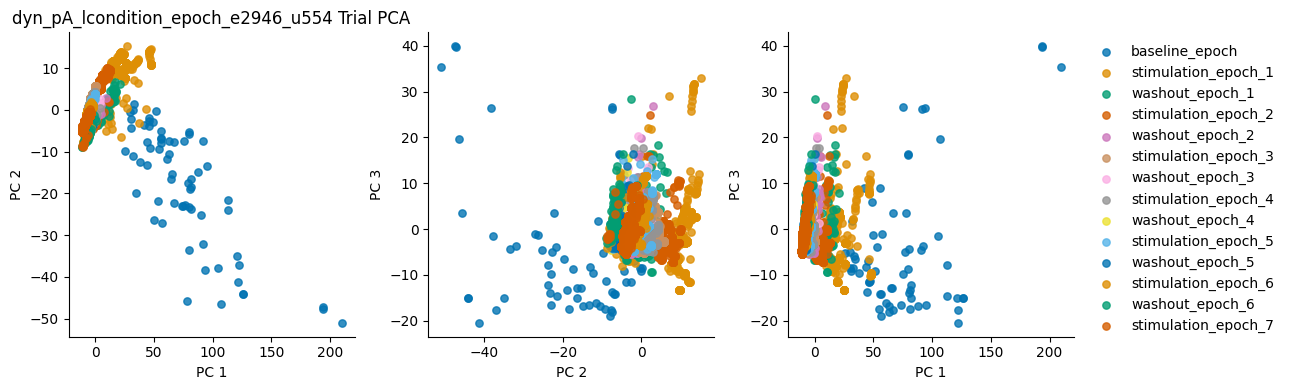

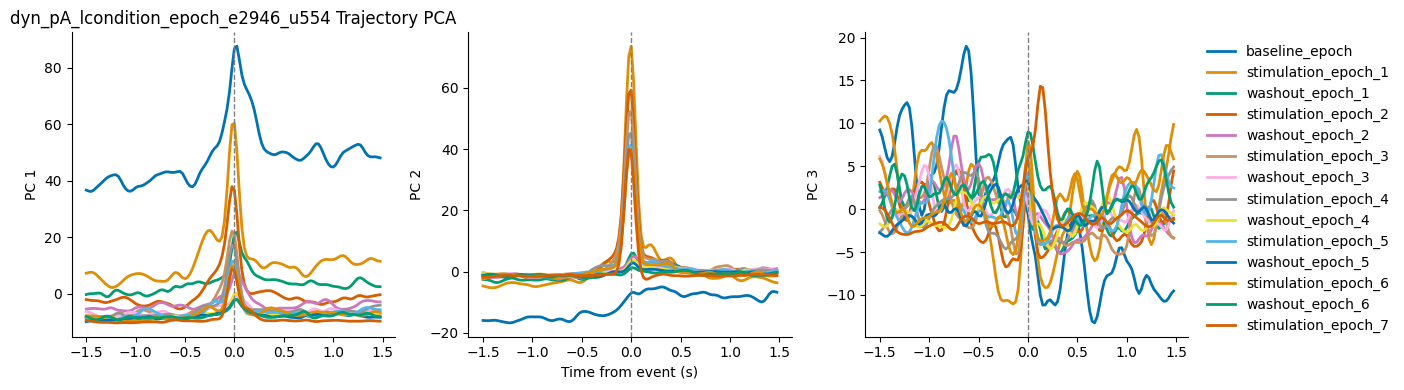

Legacy trial-level + trajectory plots complete.


In [43]:
# Dynamic family plot type 1 + 2: pca_plot_trial_level and pca_plot_trajectory
if LEGACY_RUN_TRIAL_AND_TRAJECTORY:
    _label_col_map = {
        "stimulus": "stimulus",
        "condition": "condition",
        "condition_epoch": "condition_epoch",
    }
    _label_mode_key = str(LEGACY_LABEL_MODE).strip().lower()
    if _label_mode_key not in _label_col_map:
        raise ValueError(f"Unknown LEGACY_LABEL_MODE={LEGACY_LABEL_MODE}. Use one of {list(_label_col_map.keys())}")

    _label_col = _label_col_map[_label_mode_key]
    if _label_col not in legacy_events_df.columns:
        raise ValueError(f"Label column '{_label_col}' not found in legacy_events_df")

    legacy_events_for_pca = legacy_events_df.copy()
    legacy_events_for_pca[_label_col] = legacy_events_for_pca[_label_col].astype(str)

    if LEGACY_SELECTED_LABELS is not None:
        _keep_labels = {str(x) for x in LEGACY_SELECTED_LABELS}
        legacy_events_for_pca = legacy_events_for_pca[
            legacy_events_for_pca[_label_col].isin(_keep_labels)
        ].reset_index(drop=True)

    if LEGACY_MAX_EVENTS_TOTAL is not None and len(legacy_events_for_pca) > int(LEGACY_MAX_EVENTS_TOTAL):
        _n_keep = int(LEGACY_MAX_EVENTS_TOTAL)
        _idx = np.linspace(0, len(legacy_events_for_pca) - 1, _n_keep, dtype=int)
        legacy_events_for_pca = legacy_events_for_pca.iloc[_idx].reset_index(drop=True)

    if len(legacy_events_for_pca) < 2:
        raise ValueError("Need at least 2 events for trial-level/trajectory PCA.")

    _legacy_probe_df = plots.pca_get_probe_units_df(
        merged_dic=merged_dic,
        probe=LEGACY_PROBE,
        roi_filter=EPOCH_PCA_ROI_FILTER,
        kslabel_filter=EPOCH_PCA_EFFECTIVE_KSLABEL_FILTER,
        bc_label_filter=EPOCH_PCA_EFFECTIVE_BC_LABEL_FILTER,
    )

    if LEGACY_BRAIN_REGION is not None:
        if "brain_region" not in _legacy_probe_df.columns:
            raise ValueError("LEGACY_BRAIN_REGION requested but brain_region column is missing.")
        _norm_br = getattr(plots, "_normalize_brain_region_value", lambda x: str(x).strip())
        _legacy_probe_df = _legacy_probe_df[
            _legacy_probe_df["brain_region"].map(lambda x: str(_norm_br(x)).strip()) == str(LEGACY_BRAIN_REGION)
        ].reset_index(drop=True)

    if len(_legacy_probe_df) == 0:
        raise ValueError("No units remain after legacy probe/region filters.")

    _spike_times = [np.asarray(x, dtype=float) for x in _legacy_probe_df["spike_times"].values]
    _event_times = pd.to_numeric(legacy_events_for_pca["start_time"], errors="coerce").to_numpy(dtype=float)
    _event_labels = legacy_events_for_pca[_label_col].astype(str).to_numpy()

    legacy_trials, legacy_time = plots.pca_bin_spikes_around_events(
        spike_times_list=_spike_times,
        event_times_s=_event_times,
        win_start_s=WINDOW_START_S,
        win_end_s=WINDOW_END_S,
        bin_size_s=BIN_SIZE_S,
        max_tensor_gb=MAX_TENSOR_GB,
    )

    Xp_legacy, evr_legacy, trial_types_legacy, t_type_ind_legacy = plots.pca_trial_level(
        legacy_trials,
        _event_labels,
        n_components=LEGACY_N_COMPONENTS,
    )

    _legacy_title = f"dyn_p{LEGACY_PROBE}_l{_label_col}_e{len(_event_times)}_u{len(_spike_times)}"

    plots.pca_plot_trial_level(
        Xp=Xp_legacy,
        trial_types=trial_types_legacy,
        t_type_ind=t_type_ind_legacy,
        title_prefix=_legacy_title,
        save_root=LEGACY_SAVE_ROOT,
        show_plots=LEGACY_SHOW_PLOTS,
    )

    Xa_legacy, evr_traj_legacy, kept_labels_legacy = plots.pca_trajectory(
        legacy_trials,
        _event_labels,
        n_components=LEGACY_N_COMPONENTS,
    )

    plots.pca_plot_trajectory(
        Xa_p=Xa_legacy,
        kept_labels=kept_labels_legacy,
        n_bins=legacy_trials.shape[2],
        time=legacy_time,
        smooth_sigma=LEGACY_SMOOTH_SIGMA,
        title_prefix=_legacy_title,
        save_root=LEGACY_SAVE_ROOT,
        show_plots=LEGACY_SHOW_PLOTS,
    )

    print("Legacy trial-level + trajectory plots complete.")
else:
    print("LEGACY_RUN_TRIAL_AND_TRAJECTORY=False; skipping this section.")

Requested tensor shape=(270, 554, 120) est_mem=0.07 GB
Requested tensor shape=(1900, 554, 120) est_mem=0.47 GB
Requested tensor shape=(130, 554, 120) est_mem=0.03 GB
Requested tensor shape=(376, 554, 120) est_mem=0.09 GB
Requested tensor shape=(270, 554, 120) est_mem=0.07 GB


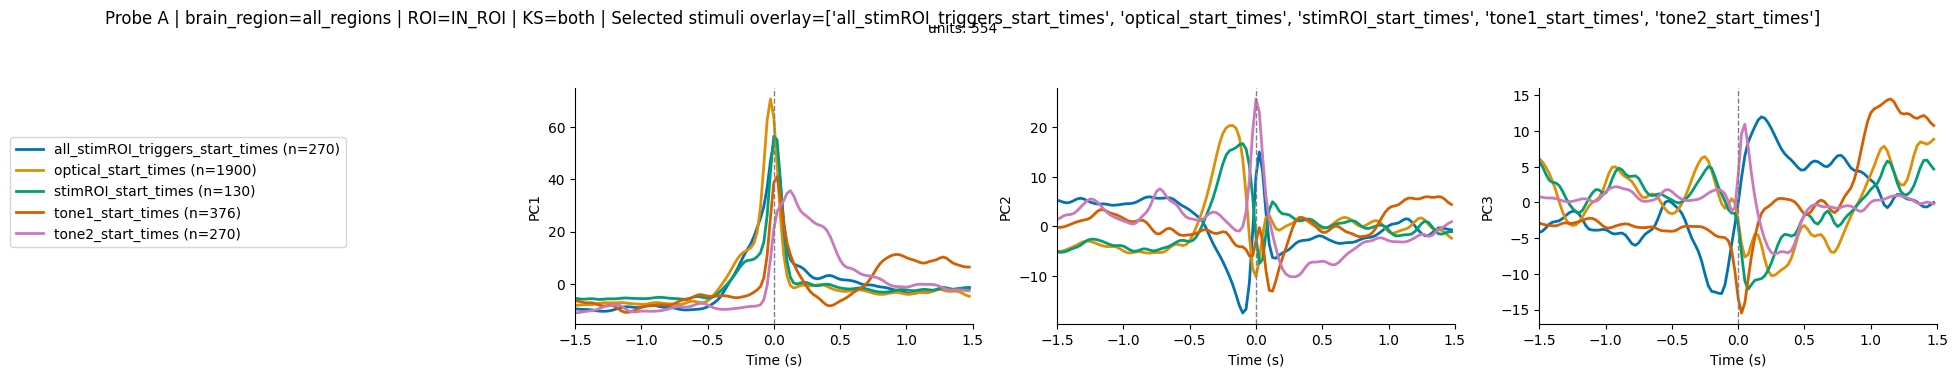

Legacy selected-stimuli overlay complete.
Requested tensor shape=(270, 554, 120) est_mem=0.07 GB
Requested tensor shape=(1900, 554, 120) est_mem=0.47 GB
Requested tensor shape=(130, 554, 120) est_mem=0.03 GB
Requested tensor shape=(376, 554, 120) est_mem=0.09 GB
Requested tensor shape=(270, 554, 120) est_mem=0.07 GB
Saved panel: H:\PCA_OUT\Reach15_20260201_session007_NP_Recording_Number02_2026-02-01_18-25-00\bd538bc6b4\dyn\pan\sp_bp\probe_A_all_regions_stimulus_panel_ROI_IN_ROI_KS_both.png


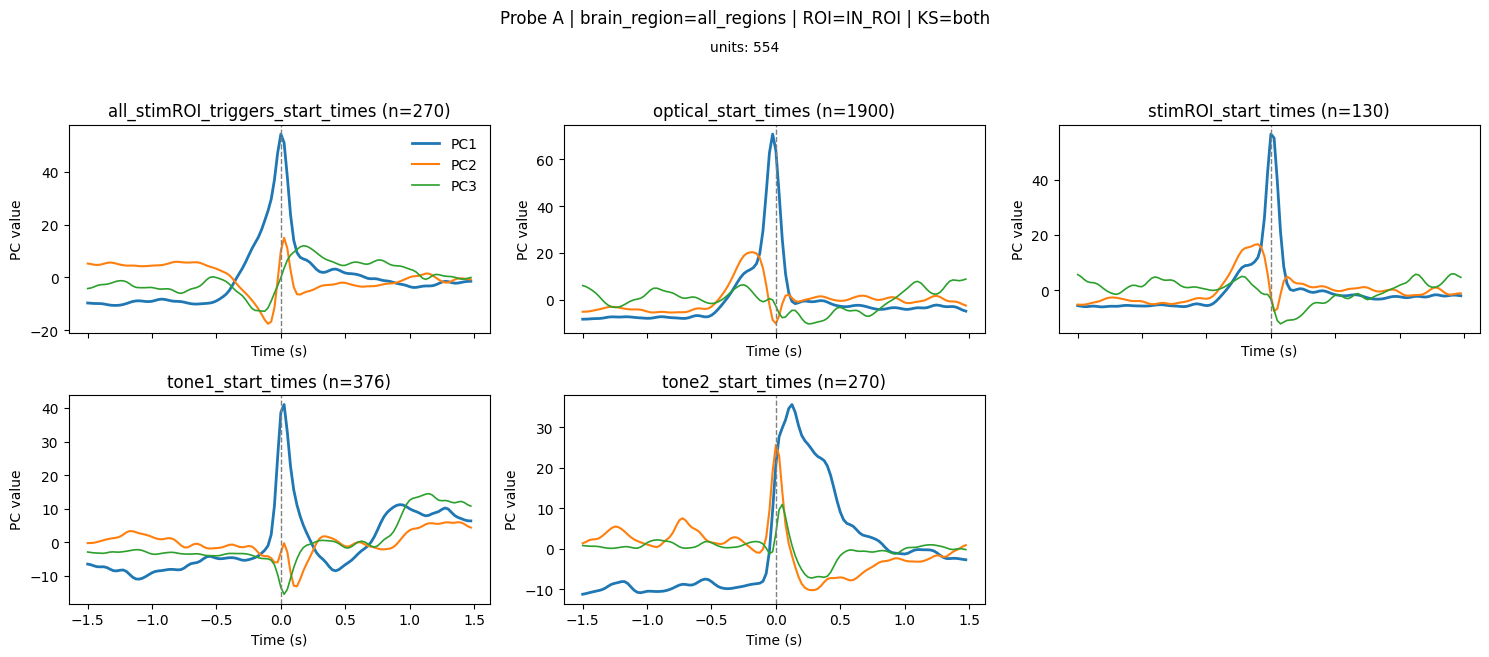

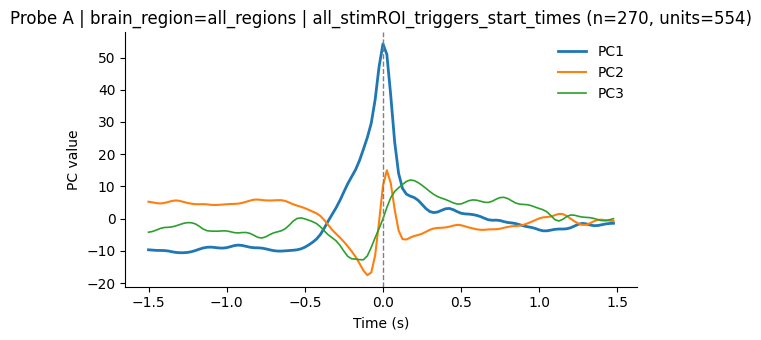

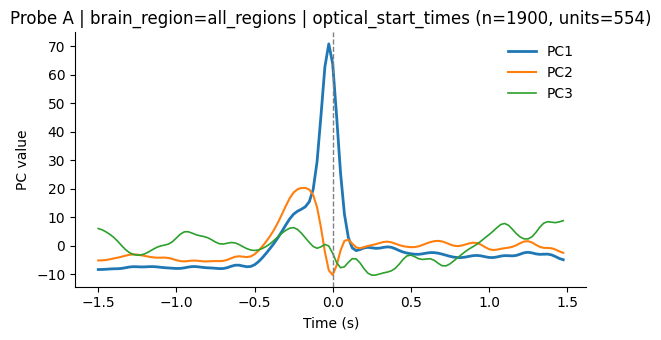

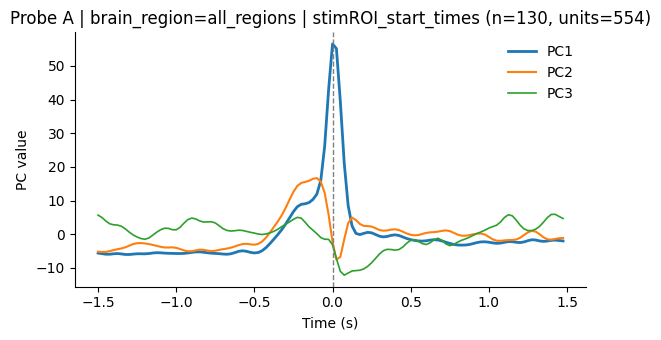

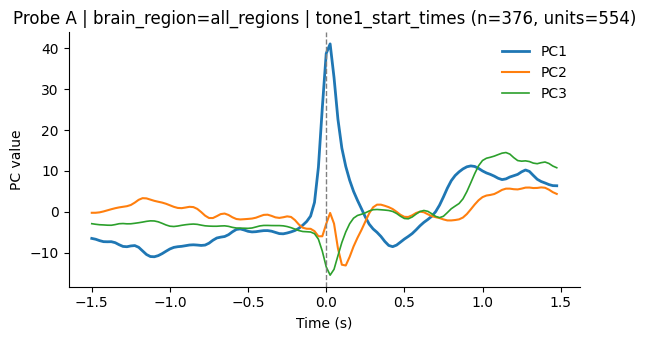

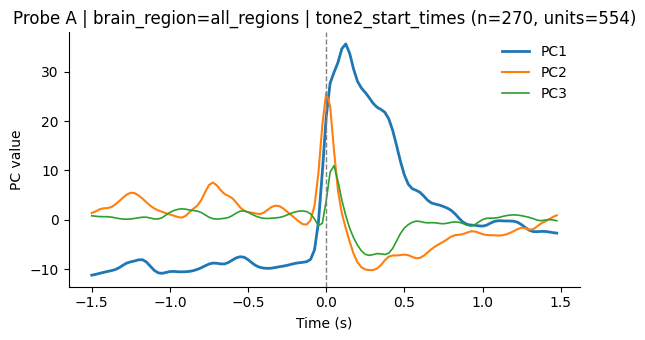

Legacy stimulus panel plots complete.


In [44]:
# Dynamic family plot type 3 + 4: plot_probe_selected_stimuli_overlay and plot_probe_stimulus_panel
import inspect

def _supported_kwargs(fn, kwargs_dict):
    sig = inspect.signature(fn)
    return {k: v for k, v in kwargs_dict.items() if k in sig.parameters}

if LEGACY_RUN_SELECTED_OVERLAY or LEGACY_RUN_STIM_PANEL:
    _stim_events_df = legacy_events_df.copy()
    if LEGACY_MAX_EVENTS_PER_STIM is not None:
        print(f"LEGACY_MAX_EVENTS_PER_STIM={LEGACY_MAX_EVENTS_PER_STIM} will be applied by plotting helpers.")

    _available_stimuli = sorted(_stim_events_df["stimulus"].astype(str).unique().tolist())
    _selected_stimuli = _available_stimuli if LEGACY_OVERLAY_STIMULI is None else [
        s for s in LEGACY_OVERLAY_STIMULI if str(s) in _available_stimuli
    ]

    if LEGACY_RUN_SELECTED_OVERLAY:
        if len(_selected_stimuli) < 2:
            print("Need at least 2 stimuli for overlay; skipping overlay plot.")
        else:
            _overlay_kwargs = {
                "probe": LEGACY_PROBE,
                "merged_dic": merged_dic,
                "events_df": _stim_events_df,
                "selected_stimuli": _selected_stimuli,
                "stim_label_col": "stimulus",
                "time_col": "start_time",
                "roi_filter": EPOCH_PCA_ROI_FILTER,
                "kslabel_filter": EPOCH_PCA_EFFECTIVE_KSLABEL_FILTER,
                "brain_region_filter": LEGACY_BRAIN_REGION,
                "n_components": LEGACY_N_COMPONENTS,
                "smooth_sigma": LEGACY_SMOOTH_SIGMA,
                "max_tensor_gb": MAX_TENSOR_GB,
                "max_events_per_stim": LEGACY_MAX_EVENTS_PER_STIM,
                "win_start_s": WINDOW_START_S,
                "win_end_s": WINDOW_END_S,
                "bin_size_s": BIN_SIZE_S,
                "save_dir": Path(LEGACY_SAVE_ROOT) / "ovr",
                "save_root": LEGACY_SAVE_ROOT,
                "show_plots": LEGACY_SHOW_PLOTS,
            }
            plots.plot_probe_selected_stimuli_overlay(
                **_supported_kwargs(plots.plot_probe_selected_stimuli_overlay, _overlay_kwargs)
            )
            print("Legacy selected-stimuli overlay complete.")

    if LEGACY_RUN_STIM_PANEL:
        _panel_kwargs = {
            "probe": LEGACY_PROBE,
            "merged_dic": merged_dic,
            "events_df": _stim_events_df,
            "stim_label_col": "stimulus",
            "time_col": "start_time",
            "roi_filter": EPOCH_PCA_ROI_FILTER,
            "kslabel_filter": EPOCH_PCA_EFFECTIVE_KSLABEL_FILTER,
            "brain_region_filter": LEGACY_BRAIN_REGION,
            "n_components": LEGACY_N_COMPONENTS,
            "smooth_sigma": LEGACY_SMOOTH_SIGMA,
            "max_tensor_gb": MAX_TENSOR_GB,
            "max_events_per_stim": LEGACY_MAX_EVENTS_PER_STIM,
            "ncols": 3,
            "one_stim_per_fig": True,
            "panel_per_probe": True,
            "win_start_s": WINDOW_START_S,
            "win_end_s": WINDOW_END_S,
            "bin_size_s": BIN_SIZE_S,
            "save_dir": Path(LEGACY_SAVE_ROOT) / "pan",
            "save_root": LEGACY_SAVE_ROOT,
            "show_plots": LEGACY_SHOW_PLOTS,
        }
        plots.plot_probe_stimulus_panel(
            **_supported_kwargs(plots.plot_probe_stimulus_panel, _panel_kwargs)
        )
        print("Legacy stimulus panel plots complete.")
else:
    print("Both LEGACY_RUN_SELECTED_OVERLAY and LEGACY_RUN_STIM_PANEL are False; skipping this section.")